In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aklduiawrh/soc-dataset/occupancy.csv
/kaggle/input/datasets/aklduiawrh/soc-dataset/distance.csv
/kaggle/input/datasets/aklduiawrh/soc-dataset/acndata_sessions.json.xlsx
/kaggle/input/datasets/aklduiawrh/soc-dataset/adj.csv
/kaggle/input/datasets/aklduiawrh/soc-dataset/stations.csv
/kaggle/input/datasets/aklduiawrh/soc-dataset/information.csv
/kaggle/input/datasets/aklduiawrh/soc-dataset/volume.csv
/kaggle/input/datasets/aklduiawrh/soc-dataset/time.csv
/kaggle/input/datasets/aklduiawrh/soc-dataset/duration.csv
/kaggle/input/datasets/aklduiawrh/soc-dataset/price.csv


# Comment is added

# ChargeOpt-AI: Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks

This notebook implements the project end-to-end using the uploaded ACN + Shenzhen/UrbanEV data.

## What this notebook does

1. Loads raw ACN session-level data and Shenzhen time-series data.
2. Cleans and converts both datasets to a unified station-hour format.
3. Performs EDA for demand, utilization, congestion, and pricing behavior.
4. Builds a Demand Prediction Agent to forecast next-hour utilization.
5. Builds a Tariff Pricing Agent to recommend dynamic ₹/kWh tariffs.
6. Builds a Monitoring & Learning Agent to compare outcomes and update pricing sensitivity.
7. Saves all final CSV outputs and plots.

Important assumption: ACN prices are not directly observed, so ACN revenue uses a ₹15/kWh fixed baseline. Shenzhen prices are in original local units and converted to an INR-scenario using a conversion factor only for comparison.

In [5]:
from pathlib import Path
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print("Folder:", dirname)
    for filename in filenames:
        print("   ", filename)

Folder: /kaggle/input
Folder: /kaggle/input/datasets
Folder: /kaggle/input/datasets/aklduiawrh
Folder: /kaggle/input/datasets/aklduiawrh/soc-dataset
    occupancy.csv
    distance.csv
    acndata_sessions.json.xlsx
    adj.csv
    stations.csv
    information.csv
    volume.csv
    time.csv
    duration.csv
    price.csv


In [6]:
# =========================
# 0. Imports and setup
# =========================

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

# Correct Kaggle input folder
DATA_DIR = Path("/kaggle/input/datasets/aklduiawrh/soc-dataset")

# Kaggle output folder
# /kaggle/input is read-only, so save all generated files in /kaggle/working
OUTPUT_DIR = Path("/kaggle/working/ev_tariff_outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "acn": DATA_DIR / "acndata_sessions.json.xlsx",
    "adj": DATA_DIR / "adj.csv",
    "distance": DATA_DIR / "distance.csv",
    "duration": DATA_DIR / "duration.csv",
    "information": DATA_DIR / "information.csv",
    "occupancy": DATA_DIR / "occupancy.csv",
    "price": DATA_DIR / "price.csv",
    "stations": DATA_DIR / "stations.csv",
    "time": DATA_DIR / "time.csv",
    "volume": DATA_DIR / "volume.csv",
}

for name, path in FILES.items():
    print(name, "=>", path, "| exists:", path.exists())

acn => /kaggle/input/datasets/aklduiawrh/soc-dataset/acndata_sessions.json.xlsx | exists: True
adj => /kaggle/input/datasets/aklduiawrh/soc-dataset/adj.csv | exists: True
distance => /kaggle/input/datasets/aklduiawrh/soc-dataset/distance.csv | exists: True
duration => /kaggle/input/datasets/aklduiawrh/soc-dataset/duration.csv | exists: True
information => /kaggle/input/datasets/aklduiawrh/soc-dataset/information.csv | exists: True
occupancy => /kaggle/input/datasets/aklduiawrh/soc-dataset/occupancy.csv | exists: True
price => /kaggle/input/datasets/aklduiawrh/soc-dataset/price.csv | exists: True
stations => /kaggle/input/datasets/aklduiawrh/soc-dataset/stations.csv | exists: True
time => /kaggle/input/datasets/aklduiawrh/soc-dataset/time.csv | exists: True
volume => /kaggle/input/datasets/aklduiawrh/soc-dataset/volume.csv | exists: True


## 1. Dataset inspection

Before modeling, always inspect the shape and columns. This avoids wrong assumptions about timestamps, station IDs, or units.

In [7]:
# =========================
# 1. Inspect uploaded files
# =========================

for name, path in FILES.items():
    print("\n" + "=" * 80)
    print("FILE KEY:", name)
    print("FILE PATH:", path)
    print("=" * 80)

    if not path.exists():
        print("Missing file:", path)
        continue

    try:
        if path.suffix.lower() == ".csv":
            temp = pd.read_csv(path, nrows=5)
            print("Preview shape:", temp.shape)
            print("First columns:", temp.columns[:15].tolist())
            display(temp.head(2))

        elif path.suffix.lower() == ".xlsx":
            temp = pd.read_excel(path, nrows=5)
            print("Preview shape:", temp.shape)
            print("First columns:", temp.columns[:20].tolist())
            display(temp.head(2))

        else:
            print("Unsupported file type:", path.suffix)

    except Exception as e:
        print("Error reading file:", e)


FILE KEY: acn
FILE PATH: /kaggle/input/datasets/aklduiawrh/soc-dataset/acndata_sessions.json.xlsx
Preview shape: (5, 27)
First columns: ['_meta', 'end', 'min_kWh', 'site', 'start', '_items', '_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'userInputs', 'WhPerMile']


,_meta,end,min_kWh,site,start,_items,_id,clusterID,connectionTime,disconnectTime,...,userID,userInputs,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,NaN,NaN,NaN,caltech,NaN,NaN,5bc90cb9f9af8b0d7fe77cd2,39,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd3,39,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



FILE KEY: adj
FILE PATH: /kaggle/input/datasets/aklduiawrh/soc-dataset/adj.csv
Preview shape: (5, 248)
First columns: ['node_id', '102', '105', '107', '108', '109', '110', '111', '115', '123', '124', '202', '204', '205', '206']


,node_id,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,102,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,105,0,1,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0



FILE KEY: distance
FILE PATH: /kaggle/input/datasets/aklduiawrh/soc-dataset/distance.csv
Preview shape: (5, 248)
First columns: ['Unnamed: 0', '102', '105', '107', '108', '109', '110', '111', '115', '123', '124', '202', '204', '205', '206']


...

,station_id,latitude,longitude,fast,slow,count
0,1,22.716272,113.826349,5,5,10
1,2,22.678851,114.049721,20,0,20



FILE KEY: time
FILE PATH: /kaggle/input/datasets/aklduiawrh/soc-dataset/time.csv
Preview shape: (5, 6)
First columns: ['month', 'day', 'year', 'hour', 'minute', 'second']


,month,day,year,hour,minute,second
0,6,19,2022,0,0,0
1,6,19,2022,0,5,0



FILE KEY: volume
FILE PATH: /kaggle/input/datasets/aklduiawrh/soc-dataset/volume.csv
Preview shape: (5, 248)
First columns: ['timestamp', '102', '105', '107', '108', '109', '110', '111', '115', '123', '124', '202', '204', '205', '206']


,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,1,2.858333,5.907222,6.478889,5.145,2.286667,3.048889,5.526111,0.381111,0.762222,...,0.0,2.286667,0.381111,12.195556,8.956111,240.236111,5.335556,0.381111,2.286667,2.096111
1,2,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,367.708333,8.166667,0.583333,3.500000,3.208333


## 2. ACN preprocessing

ACN is session-level data. Each row is one charging session. To make it comparable with Shenzhen, we convert it into **station-hour data**.

Instead of putting the full energy into the connection hour, this code distributes the session energy across active charging hours using overlap duration. That is more realistic.

In [8]:
# =========================
# 2. ACN preprocessing
# =========================

def load_acn_hourly(acn_path: Path) -> pd.DataFrame:
    """
    Loads ACN session-level Excel file and converts it into station-hour level data.

    Input:
        acn_path: Path to acndata_sessions.json.xlsx

    Output:
        acn_hourly: DataFrame where each row = one ACN station in one hour
    """

    # -------------------------
    # 1. Read ACN Excel file
    # -------------------------
    acn = pd.read_excel(acn_path)

    print("Raw ACN shape:", acn.shape)
    print("Raw ACN columns:")
    print(acn.columns.tolist())

    # -------------------------
    # 2. Keep only useful columns
    # -------------------------
    useful_cols = [
        "connectionTime",
        "disconnectTime",
        "doneChargingTime",
        "kWhDelivered",
        "stationID",
        "spaceID",
        "site",
        "siteID"
    ]

    useful_cols = [col for col in useful_cols if col in acn.columns]

    acn = acn[useful_cols].copy()

    print("Useful ACN columns used:")
    print(useful_cols)

    # -------------------------
    # 3. Check required columns
    # -------------------------
    required_cols = ["connectionTime", "disconnectTime", "kWhDelivered"]

    for col in required_cols:
        if col not in acn.columns:
            raise ValueError(f"Required column missing in ACN file: {col}")

    if "stationID" not in acn.columns and "spaceID" not in acn.columns:
        raise ValueError("Both stationID and spaceID are missing. Need one station identifier.")

    # -------------------------
    # 4. Convert timestamp columns
    # -------------------------
    for col in ["connectionTime", "disconnectTime", "doneChargingTime"]:
        if col in acn.columns:
            acn[col] = pd.to_datetime(acn[col], errors="coerce", utc=True)

    # -------------------------
    # 5. Basic missing value handling
    # -------------------------
    acn = acn.dropna(subset=["connectionTime", "disconnectTime", "kWhDelivered"])

    # If doneChargingTime column is missing, create it
    if "doneChargingTime" not in acn.columns:
        acn["doneChargingTime"] = acn["disconnectTime"]

    # If doneChargingTime is null, assume charging lasted until disconnect
    acn["doneChargingTime"] = acn["doneChargingTime"].fillna(acn["disconnectTime"])

    # Charging cannot finish after disconnect for our usage calculation
    acn["doneChargingTime"] = acn[["doneChargingTime", "disconnectTime"]].min(axis=1)

    # Convert energy to numeric
    acn["kWhDelivered"] = pd.to_numeric(acn["kWhDelivered"], errors="coerce")
    acn = acn.dropna(subset=["kWhDelivered"])

    # -------------------------
    # 6. Remove invalid sessions
    # -------------------------
    acn = acn[
        (acn["disconnectTime"] > acn["connectionTime"]) &
        (acn["doneChargingTime"] >= acn["connectionTime"]) &
        (acn["kWhDelivered"] >= 0)
    ].copy()

    # -------------------------
    # 7. Duration features
    # -------------------------
    acn["session_duration_hours"] = (
        acn["disconnectTime"] - acn["connectionTime"]
    ).dt.total_seconds() / 3600

    acn["charging_duration_hours"] = (
        acn["doneChargingTime"] - acn["connectionTime"]
    ).dt.total_seconds() / 3600

    # Keep sessions up to 48 hours to remove extreme outliers
    acn = acn[
        (acn["session_duration_hours"] > 0) &
        (acn["session_duration_hours"] <= 48) &
        (acn["charging_duration_hours"] >= 0) &
        (acn["charging_duration_hours"] <= 48)
    ].copy()

    # -------------------------
    # 8. Convert to Caltech local time
    # -------------------------
    for col in ["connectionTime", "disconnectTime", "doneChargingTime"]:
        acn[col] = acn[col].dt.tz_convert("America/Los_Angeles")

    # -------------------------
    # 9. Create station id
    # -------------------------
    if "stationID" in acn.columns:
        acn["station_id"] = "ACN_" + acn["stationID"].astype(str)
    else:
        acn["station_id"] = "ACN_" + acn["spaceID"].astype(str)

    # -------------------------
    # 10. Allocate charging energy across active hours
    # -------------------------
    rows = []

    for row in acn.itertuples(index=False):
        station_id = row.station_id
        start = row.connectionTime
        end = row.doneChargingTime
        kwh = float(row.kWhDelivered)

        charging_hours = max((end - start).total_seconds() / 3600, 0)

        if charging_hours <= 0:
            continue

        current_hour = start.floor("h")

        while current_hour < end:
            next_hour = current_hour + pd.Timedelta(hours=1)

            overlap_start = max(start, current_hour)
            overlap_end = min(end, next_hour)

            overlap_hours = max(
                (overlap_end - overlap_start).total_seconds() / 3600,
                0
            )

            if overlap_hours > 0:
                allocated_kwh = kwh * overlap_hours / charging_hours

                rows.append({
                    "station_id": station_id,
                    "timestamp": current_hour.tz_localize(None),
                    "demand_kwh": allocated_kwh,
                    "charging_duration_hours": overlap_hours
                })

            current_hour = next_hour

    active = pd.DataFrame(rows)

    if active.empty:
        raise ValueError("No active charging rows were created from ACN data.")

    # -------------------------
    # 11. Aggregate to station-hour level
    # -------------------------
    acn_hourly = (
        active
        .groupby(["station_id", "timestamp"], as_index=False)
        .agg(
            demand_kwh=("demand_kwh", "sum"),
            charging_duration_hours=("charging_duration_hours", "sum")
        )
    )

    # -------------------------
    # 12. Count number of sessions starting each hour
    # -------------------------
    starts = (
        acn
        .assign(timestamp=acn["connectionTime"].dt.floor("h").dt.tz_localize(None))
        .groupby(["station_id", "timestamp"])
        .size()
        .reset_index(name="num_sessions")
    )

    acn_hourly = acn_hourly.merge(
        starts,
        on=["station_id", "timestamp"],
        how="left"
    )

    acn_hourly["num_sessions"] = acn_hourly["num_sessions"].fillna(0)

    # -------------------------
    # 13. Capacity and utilization assumptions
    # -------------------------
    # ACN station capacity metadata is not in this uploaded file.
    # So we assume each stationID represents one plug.
    acn_hourly["station_capacity"] = 1

    # Since each row is one hour:
    # utilization = active charging hours / available charger hours
    acn_hourly["utilization_rate"] = (
        acn_hourly["charging_duration_hours"] / acn_hourly["station_capacity"]
    ).clip(0, 1)

    acn_hourly["occupancy_count"] = (
        acn_hourly["utilization_rate"] * acn_hourly["station_capacity"]
    )

    # -------------------------
    # 14. Baseline tariff and revenue
    # -------------------------
    # ACN has no observed tariff, so we use project baseline tariff.
    acn_hourly["average_price"] = 15.0
    acn_hourly["revenue"] = acn_hourly["demand_kwh"] * acn_hourly["average_price"]

    # -------------------------
    # 15. Metadata columns
    # -------------------------
    acn_hourly["site"] = "Caltech"
    acn_hourly["source"] = "ACN"

    # -------------------------
    # 16. Reorder columns
    # -------------------------
    final_cols = [
        "station_id",
        "site",
        "timestamp",
        "demand_kwh",
        "num_sessions",
        "occupancy_count",
        "charging_duration_hours",
        "station_capacity",
        "utilization_rate",
        "average_price",
        "revenue",
        "source"
    ]

    acn_hourly = acn_hourly[final_cols].copy()

    print("Final ACN hourly shape:", acn_hourly.shape)

    return acn_hourly


# Run ACN preprocessing using your Kaggle FILES setup
acn_hourly = load_acn_hourly(FILES["acn"])

display(acn_hourly.head())
print(acn_hourly.shape)

Raw ACN shape: (16304, 27)
Raw ACN columns:
['_meta', 'end', 'min_kWh', 'site', 'start', '_items', '_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'userInputs', 'WhPerMile', 'kWhRequested', 'milesRequested', 'minutesAvailable', 'modifiedAt', 'paymentRequired', 'requestedDeparture', 'userID.1']
Useful ACN columns used:
['connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'stationID', 'spaceID', 'site', 'siteID']
Final ACN hourly shape: (61405, 12)


,station_id,site,timestamp,demand_kwh,num_sessions,occupancy_count,charging_duration_hours,station_capacity,utilization_rate,average_price,revenue,source
0,ACN_2-39-123-23,Caltech,2018-04-25 09:00:00,1.746067,1.0,0.976111,0.976111,1,0.976111,15.0,26.191005,ACN
1,ACN_2-39-123-23,Caltech,2018-04-25 10:00:00,1.788799,0.0,1.000000,1.000000,1,1.000000,15.0,26.831992,ACN
2,ACN_2-39-123-23,Caltech,2018-04-25 11:00:00,1.788799,0.0,1.000000,1.000000,1,1.000000,15.0,26.831992,ACN
3,ACN_2-39-123-23,Caltech,2018-04-25 12:00:00,1.788799,0.0,1.000000,1.000000,1,1.000000,15.0,26.831992,ACN
4,ACN_2-39-123-23,Caltech,2018-04-25 13:00:00,1.788799,0.0,1.000000,1.000000,1,1.000000,15.0,26.831992,ACN


(61405, 12)


## 3. Shenzhen / UrbanEV preprocessing

Shenzhen files are wide time-series matrices. Each station is a column. We first aggregate the 5-minute data into hourly data, then convert from wide to long format.

Hourly aggregation:
- `volume.csv`: sum, because kWh over the hour should be total kWh.
- `duration.csv`: sum, because charging duration accumulates.
- `occupancy.csv`: mean, because occupancy is a state.
- `price.csv`: mean, because tariff is a rate.

In [9]:
# =========================
# 3. Shenzhen / UrbanEV preprocessing
# =========================

def load_shenzhen_hourly(files: dict) -> pd.DataFrame:
    """
    Loads Shenzhen / UrbanEV 5-minute matrix data and converts it into
    station-hour level data.

    Input files used:
        volume.csv
        occupancy.csv
        duration.csv
        price.csv
        time.csv
        information.csv

    Output:
        shz_hourly: DataFrame where each row = one Shenzhen station in one hour
    """

    # -------------------------
    # 1. Load metadata and time file
    # -------------------------
    info = pd.read_csv(files["information"])
    time_df = pd.read_csv(files["time"])

    print("Information shape:", info.shape)
    print("Time shape:", time_df.shape)
    print("Time columns:", time_df.columns.tolist())
    print("Information columns:", info.columns.tolist())

    # -------------------------
    # 2. Create timestamps from time.csv
    # -------------------------
    # Your time.csv contains year, month, day, hour, minute, second columns.
    required_time_cols = ["year", "month", "day", "hour", "minute", "second"]

    for col in required_time_cols:
        if col not in time_df.columns:
            raise ValueError(f"Missing column in time.csv: {col}")

    timestamps = pd.to_datetime(
        time_df[required_time_cols],
        errors="coerce"
    )

    if timestamps.isna().sum() > 0:
        print("Warning: Some timestamps could not be parsed.")

    # -------------------------
    # 3. Helper function to read matrix files
    # -------------------------
    def read_matrix(name: str) -> pd.DataFrame:
        df = pd.read_csv(files[name])

        print(f"\n{name} raw shape:", df.shape)
        print(f"{name} first columns:", df.columns[:10].tolist())

        # Drop unnamed columns if any
        unnamed_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
        if unnamed_cols:
            df = df.drop(columns=unnamed_cols)

        # Some files may contain timestamp/index column.
        # We remove old timestamp because actual time comes from time.csv.
        if "timestamp" in df.columns:
            df = df.drop(columns=["timestamp"])

        # Make sure row count matches time.csv
        if len(df) != len(timestamps):
            raise ValueError(
                f"{name}.csv rows = {len(df)}, but time.csv rows = {len(timestamps)}"
            )

        # Insert actual timestamp
        df.insert(0, "timestamp", timestamps.values)

        return df

    volume = read_matrix("volume")
    occupancy = read_matrix("occupancy")
    duration = read_matrix("duration")
    price = read_matrix("price")

    # -------------------------
    # 4. Convert 5-minute wide matrix to hourly wide matrix
    # -------------------------
    def hourly_wide(df: pd.DataFrame, agg: str) -> pd.DataFrame:
        temp = df.copy()

        temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
        temp["timestamp_hour"] = temp["timestamp"].dt.floor("h")

        temp = temp.drop(columns=["timestamp"])

        # Convert all station columns to numeric
        station_cols = [c for c in temp.columns if c != "timestamp_hour"]

        for col in station_cols:
            temp[col] = pd.to_numeric(temp[col], errors="coerce")

        if agg == "sum":
            result = temp.groupby("timestamp_hour", as_index=False).sum(numeric_only=True)
        elif agg == "mean":
            result = temp.groupby("timestamp_hour", as_index=False).mean(numeric_only=True)
        else:
            raise ValueError("agg must be either 'sum' or 'mean'")

        result = result.rename(columns={"timestamp_hour": "timestamp"})
        return result

    # volume = total kWh in hour
    volume_h = hourly_wide(volume, "sum")

    # occupancy = average busy chargers in that hour
    occupancy_h = hourly_wide(occupancy, "mean")

    # duration = total charging duration in hour
    duration_h = hourly_wide(duration, "sum")

    # price = average tariff in that hour
    price_h = hourly_wide(price, "mean")

    print("\nHourly volume shape:", volume_h.shape)
    print("Hourly occupancy shape:", occupancy_h.shape)
    print("Hourly duration shape:", duration_h.shape)
    print("Hourly price shape:", price_h.shape)

    # -------------------------
    # 5. Convert hourly wide to long format
    # -------------------------
    def melt_hourly(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
        return df.melt(
            id_vars="timestamp",
            var_name="station_grid",
            value_name=value_name
        )

    shz = melt_hourly(volume_h, "demand_kwh")

    shz = shz.merge(
        melt_hourly(occupancy_h, "occupancy_count"),
        on=["timestamp", "station_grid"],
        how="left"
    )

    shz = shz.merge(
        melt_hourly(duration_h, "charging_duration_raw"),
        on=["timestamp", "station_grid"],
        how="left"
    )

    shz = shz.merge(
        melt_hourly(price_h, "average_price_original"),
        on=["timestamp", "station_grid"],
        how="left"
    )

    # Convert numeric values
    numeric_cols = [
        "demand_kwh",
        "occupancy_count",
        "charging_duration_raw",
        "average_price_original"
    ]

    for col in numeric_cols:
        shz[col] = pd.to_numeric(shz[col], errors="coerce")

    # Safe filling
    shz["demand_kwh"] = shz["demand_kwh"].fillna(0)
    shz["occupancy_count"] = shz["occupancy_count"].fillna(0)
    shz["charging_duration_raw"] = shz["charging_duration_raw"].fillna(0)
    shz["average_price_original"] = shz["average_price_original"].fillna(
        shz["average_price_original"].median()
    )

    # station_grid should match grid in information.csv
    shz["grid"] = pd.to_numeric(shz["station_grid"], errors="coerce")

    # -------------------------
    # 6. Prepare station metadata
    # -------------------------
    info = info.copy()

    # Rename common columns from your dataset
    rename_map = {
        "count": "station_capacity",
        "lon": "longitude",
        "la": "latitude",
        "lat": "latitude"
    }

    info = info.rename(columns={k: v for k, v in rename_map.items() if k in info.columns})

    if "grid" not in info.columns:
        raise ValueError("information.csv must contain grid column to merge metadata.")

    # Create station capacity if not directly available
    if "station_capacity" not in info.columns:
        if "fast_count" in info.columns and "slow_count" in info.columns:
            info["station_capacity"] = (
                pd.to_numeric(info["fast_count"], errors="coerce").fillna(0) +
                pd.to_numeric(info["slow_count"], errors="coerce").fillna(0)
            )
        else:
            info["station_capacity"] = np.nan

    # Keep only columns that exist
    desired_meta_cols = [
        "grid",
        "station_capacity",
        "fast_count",
        "slow_count",
        "area",
        "longitude",
        "latitude",
        "CBD",
        "dynamic_pricing"
    ]

    meta_cols = [col for col in desired_meta_cols if col in info.columns]

    info_meta = info[meta_cols].copy()

    shz = shz.merge(info_meta, on="grid", how="left")

    # -------------------------
    # 7. Station ID and capacity fallback
    # -------------------------
    shz["station_id"] = "SHZ_" + shz["station_grid"].astype(str)

    # If metadata capacity missing, estimate by max observed occupancy
    shz["station_capacity"] = pd.to_numeric(
        shz["station_capacity"],
        errors="coerce"
    )

    fallback_capacity = shz.groupby("station_id")["occupancy_count"].transform("max")

    shz["station_capacity"] = (
        shz["station_capacity"]
        .fillna(fallback_capacity)
        .replace(0, np.nan)
        .fillna(1)
    )

    # -------------------------
    # 8. Utilization, duration, price, revenue
    # -------------------------
    shz["utilization_rate"] = (
        shz["occupancy_count"] / shz["station_capacity"]
    ).clip(0, 1)

    # Duration raw may already represent minutes in the dataset.
    # We convert to hours for common interpretation.
    shz["charging_duration_hours"] = shz["charging_duration_raw"] / 60

    # Scenario conversion from Yuan/kWh to INR/kWh
    # This is for common project comparison, not a causal market claim.
    CNY_TO_INR_SCENARIO = 11.5

    shz["average_price"] = shz["average_price_original"] * CNY_TO_INR_SCENARIO

    shz["revenue"] = shz["demand_kwh"] * shz["average_price"]

    shz["num_sessions"] = np.nan
    shz["site"] = "Shenzhen"
    shz["source"] = "UrbanEV"

    # -------------------------
    # 9. Final column order
    # -------------------------
    final_cols = [
        "station_id",
        "site",
        "timestamp",
        "demand_kwh",
        "num_sessions",
        "occupancy_count",
        "charging_duration_hours",
        "station_capacity",
        "utilization_rate",
        "average_price",
        "average_price_original",
        "revenue",
        "grid",
        "station_grid",
        "source"
    ]

    # Add optional metadata columns if available
    optional_cols = [
        "fast_count",
        "slow_count",
        "area",
        "longitude",
        "latitude",
        "CBD",
        "dynamic_pricing"
    ]

    for col in optional_cols:
        if col in shz.columns:
            final_cols.append(col)

    shz_hourly = shz[final_cols].copy()

    print("\nFinal Shenzhen hourly shape:", shz_hourly.shape)

    return shz_hourly


# Run Shenzhen preprocessing
shz_hourly = load_shenzhen_hourly(FILES)

display(shz_hourly.head())
print(shz_hourly.shape)

Information shape: (247, 10)
Time shape: (8640, 6)
Time columns: ['month', 'day', 'year', 'hour', 'minute', 'second']
Information columns: ['num', 'grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'CBD', 'dynamic_pricing']

volume raw shape: (8640, 248)
volume first columns: ['timestamp', '102', '105', '107', '108', '109', '110', '111', '115', '123']

occupancy raw shape: (8640, 248)
occupancy first columns: ['timestamp', '102', '105', '107', '108', '109', '110', '111', '115', '123']

duration raw shape: (8640, 248)
duration first columns: ['timestamp', '102', '105', '107', '108', '109', '110', '111', '115', '123']

price raw shape: (8640, 248)
price first columns: ['timestamp', '102', '105', '107', '108', '109', '110', '111', '115', '123']

Hourly volume shape: (720, 248)
Hourly occupancy shape: (720, 248)
Hourly duration shape: (720, 248)
Hourly price shape: (720, 248)

Final Shenzhen hourly shape: (177840, 22)


,station_id,site,timestamp,demand_kwh,num_sessions,occupancy_count,charging_duration_hours,station_capacity,utilization_rate,average_price,...,grid,station_grid,source,fast_count,slow_count,area,longitude,latitude,CBD,dynamic_pricing
0,SHZ_102,Shenzhen,2022-06-19 00:00:00,50.983333,NaN,12.0,0.145667,30,0.4,10.626,...,102,102,UrbanEV,3,27,0.71,114.103,22.54041,0,0
1,SHZ_102,Shenzhen,2022-06-19 01:00:00,52.500000,NaN,12.0,0.150000,30,0.4,10.626,...,102,102,UrbanEV,3,27,0.71,114.103,22.54041,0,0
2,SHZ_102,Shenzhen,2022-06-19 02:00:00,52.500000,NaN,12.0,0.150000,30,0.4,10.626,...,102,102,UrbanEV,3,27,0.71,114.103,22.54041,0,0
3,SHZ_102,Shenzhen,2022-06-19 03:00:00,52.500000,NaN,12.0,0.150000,30,0.4,10.626,...,102,102,UrbanEV,3,27,0.71,114.103,22.54041,0,0
4,SHZ_102,Shenzhen,2022-06-19 04:00:00,52.500000,NaN,12.0,0.150000,30,0.4,10.626,...,102,102,UrbanEV,3,27,0.71,114.103,22.54041,0,0


(177840, 22)


## 4. Unified station-hour dataset

Now we align both sources into one common schema. This is the modeling base for all further tasks.

In [10]:
# =========================
# 4. Combine ACN and Shenzhen
# =========================

final_cols = [
    "station_id", "site", "timestamp",
    "demand_kwh", "num_sessions", "occupancy_count",
    "charging_duration_hours", "station_capacity", "utilization_rate",
    "average_price", "revenue", "source",
    "grid", "fast_count", "slow_count", "area",
    "longitude", "latitude", "CBD", "dynamic_pricing",
    "average_price_original"
]

# Add missing columns to both datasets
for col in final_cols:
    if col not in acn_hourly.columns:
        acn_hourly[col] = np.nan

    if col not in shz_hourly.columns:
        shz_hourly[col] = np.nan

# Combine both sources
cleaned = pd.concat(
    [
        acn_hourly[final_cols],
        shz_hourly[final_cols]
    ],
    ignore_index=True
)

# Convert timestamp
cleaned["timestamp"] = pd.to_datetime(cleaned["timestamp"], errors="coerce")

# Drop rows where main identity columns are missing
cleaned = cleaned.dropna(subset=["station_id", "timestamp"])

# Convert numeric columns safely
numeric_cols = [
    "demand_kwh",
    "num_sessions",
    "occupancy_count",
    "charging_duration_hours",
    "station_capacity",
    "utilization_rate",
    "average_price",
    "revenue",
    "grid",
    "fast_count",
    "slow_count",
    "longitude",
    "latitude",
    "CBD",
    "dynamic_pricing",
    "average_price_original"
]

for col in numeric_cols:
    if col in cleaned.columns:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

# Fill safe missing values
cleaned["demand_kwh"] = cleaned["demand_kwh"].fillna(0)
cleaned["num_sessions"] = cleaned["num_sessions"].fillna(0)
cleaned["occupancy_count"] = cleaned["occupancy_count"].fillna(0)
cleaned["charging_duration_hours"] = cleaned["charging_duration_hours"].fillna(0)
cleaned["station_capacity"] = cleaned["station_capacity"].replace(0, np.nan).fillna(1)
cleaned["average_price"] = cleaned["average_price"].fillna(15)

# Recompute utilization if missing
missing_util = cleaned["utilization_rate"].isna()

cleaned.loc[missing_util, "utilization_rate"] = (
    cleaned.loc[missing_util, "occupancy_count"] /
    cleaned.loc[missing_util, "station_capacity"]
)

cleaned["utilization_rate"] = cleaned["utilization_rate"].clip(0, 1)

# Recompute revenue if missing
cleaned["revenue"] = cleaned["revenue"].fillna(
    cleaned["demand_kwh"] * cleaned["average_price"]
)

# Temporal features
cleaned["hour"] = cleaned["timestamp"].dt.hour
cleaned["day_of_week"] = cleaned["timestamp"].dt.dayofweek
cleaned["is_weekend"] = cleaned["day_of_week"].isin([5, 6]).astype(int)
cleaned["month"] = cleaned["timestamp"].dt.month
cleaned["date"] = cleaned["timestamp"].dt.date

# Congestion proxy: utilization above 80%
cleaned["queue_proxy"] = (cleaned["utilization_rate"] - 0.8).clip(lower=0)

# Utilization status
cleaned["utilization_status"] = np.select(
    [
        cleaned["utilization_rate"] > 0.8,
        cleaned["utilization_rate"] < 0.3
    ],
    [
        "overloaded",
        "underutilized"
    ],
    default="normal"
)

# Final safety filtering
cleaned = cleaned[
    (cleaned["demand_kwh"] >= 0) &
    (cleaned["occupancy_count"] >= 0) &
    (cleaned["station_capacity"] > 0) &
    (cleaned["utilization_rate"] >= 0) &
    (cleaned["utilization_rate"] <= 1)
].copy()

# Sort for time-series modeling
cleaned = cleaned.sort_values(
    ["source", "station_id", "timestamp"]
).reset_index(drop=True)

# Save cleaned dataset
cleaned.to_csv(OUTPUT_DIR / "cleaned_station_hour_data.csv", index=False)

print("Final cleaned shape:", cleaned.shape)
display(cleaned.head())
display(cleaned.tail())

Final cleaned shape: (239245, 28)


,station_id,site,timestamp,demand_kwh,num_sessions,occupancy_count,charging_duration_hours,station_capacity,utilization_rate,average_price,...,CBD,dynamic_pricing,average_price_original,hour,day_of_week,is_weekend,month,date,queue_proxy,utilization_status
0,ACN_2-39-123-23,Caltech,2018-04-25 09:00:00,1.746067,1.0,0.976111,0.976111,1,0.976111,15.0,...,NaN,NaN,NaN,9,2,0,4,2018-04-25,0.176111,overloaded
1,ACN_2-39-123-23,Caltech,2018-04-25 10:00:00,1.788799,0.0,1.000000,1.000000,1,1.000000,15.0,...,NaN,NaN,NaN,10,2,0,4,2018-04-25,0.200000,overloaded
2,ACN_2-39-123-23,Caltech,2018-04-25 11:00:00,1.788799,0.0,1.000000,1.000000,1,1.000000,15.0,...,NaN,NaN,NaN,11,2,0,4,2018-04-25,0.200000,overloaded
3,ACN_2-39-123-23,Caltech,2018-04-25 12:00:00,1.788799,0.0,1.000000,1.000000,1,1.000000,15.0,...,NaN,NaN,NaN,12,2,0,4,2018-04-25,0.200000,overloaded
4,ACN_2-39-123-23,Caltech,2018-04-25 13:00:00,1.788799,0.0,1.000000,1.000000,1,1.000000,15.0,...,NaN,NaN,NaN,13,2,0,4,2018-04-25,0.200000,overloaded


,station_id,site,timestamp,demand_kwh,num_sessions,occupancy_count,charging_duration_hours,station_capacity,utilization_rate,average_price,...,CBD,dynamic_pricing,average_price_original,hour,day_of_week,is_weekend,month,date,queue_proxy,utilization_status
239240,SHZ_998,Shenzhen,2022-07-18 19:00:00,3105.317778,0.0,44.666667,0.723139,162,0.275720,10.8238,...,0.0,1.0,0.9412,19,0,0,7,2022-07-18,0.0,underutilized
239241,SHZ_998,Shenzhen,2022-07-18 20:00:00,3730.110833,0.0,51.250000,0.854667,162,0.316358,10.8238,...,0.0,1.0,0.9412,20,0,0,7,2022-07-18,0.0,normal
239242,SHZ_998,Shenzhen,2022-07-18 21:00:00,3010.857222,0.0,48.750000,0.805736,162,0.300926,10.8238,...,0.0,1.0,0.9412,21,0,0,7,2022-07-18,0.0,normal
239243,SHZ_998,Shenzhen,2022-07-18 22:00:00,3182.272222,0.0,52.666667,0.871986,162,0.325103,10.8238,...,0.0,1.0,0.9412,22,0,0,7,2022-07-18,0.0,normal
239244,SHZ_998,Shenzhen,2022-07-18 23:00:00,2958.364444,0.0,52.583333,0.866745,162,0.324588,10.8238,...,0.0,1.0,0.9412,23,0,0,7,2022-07-18,0.0,normal


In [11]:
cleaned.to_csv(OUTPUT_DIR / "cleaned_station_hour_data.csv", index=False)

In [12]:
# =========================
# 4A. Additional economic features required by problem statement
# =========================

# Revenue per session:
# For ACN, num_sessions is available.
# For UrbanEV, num_sessions is not directly available, so this remains NaN or 0-based proxy.
cleaned["revenue_per_session"] = np.where(
    cleaned["num_sessions"] > 0,
    cleaned["revenue"] / cleaned["num_sessions"],
    np.nan
)

# Energy cost per kWh:
# In this project, average_price is treated as the effective tariff / energy price per kWh.
cleaned["energy_cost_per_kwh"] = cleaned["average_price"]

# Occupancy density:
# Busy chargers divided by station capacity.
cleaned["occupancy_density"] = (
    cleaned["occupancy_count"] / cleaned["station_capacity"].replace(0, np.nan)
).clip(0, 1)

# Save updated cleaned dataset
cleaned.to_csv(OUTPUT_DIR / "cleaned_station_hour_data.csv", index=False)

display(
    cleaned[
        [
            "station_id",
            "timestamp",
            "utilization_rate",
            "revenue_per_session",
            "energy_cost_per_kwh",
            "queue_proxy",
            "occupancy_density"
        ]
    ].head()
)

print("Updated cleaned dataset saved:", OUTPUT_DIR / "cleaned_station_hour_data.csv")

,station_id,timestamp,utilization_rate,revenue_per_session,energy_cost_per_kwh,queue_proxy,occupancy_density
0,ACN_2-39-123-23,2018-04-25 09:00:00,0.976111,26.191005,15.0,0.176111,0.976111
1,ACN_2-39-123-23,2018-04-25 10:00:00,1.000000,NaN,15.0,0.200000,1.000000
2,ACN_2-39-123-23,2018-04-25 11:00:00,1.000000,NaN,15.0,0.200000,1.000000
3,ACN_2-39-123-23,2018-04-25 12:00:00,1.000000,NaN,15.0,0.200000,1.000000
4,ACN_2-39-123-23,2018-04-25 13:00:00,1.000000,NaN,15.0,0.200000,1.000000


Updated cleaned dataset saved: /kaggle/working/ev_tariff_outputs/cleaned_station_hour_data.csv


## 5. EDA

These plots directly support pricing decisions:
- high utilization → surge pricing
- low utilization → mild discount signal
- station-level overload → infrastructure or scheduling decisions

In [13]:
# =========================
# 5A. EDA summary
# =========================

eda_summary = {
    "total_rows": len(cleaned),
    "total_stations": cleaned["station_id"].nunique(),
    "sources": ", ".join(cleaned["source"].dropna().unique()),
    "start_date": cleaned["timestamp"].min(),
    "end_date": cleaned["timestamp"].max(),
    "avg_utilization": cleaned["utilization_rate"].mean(),
    "median_utilization": cleaned["utilization_rate"].median(),
    "avg_demand_kwh": cleaned["demand_kwh"].mean(),
    "total_demand_kwh": cleaned["demand_kwh"].sum(),
    "total_revenue": cleaned["revenue"].sum(),
    "avg_price": cleaned["average_price"].mean(),
    "overloaded_share_pct": cleaned["utilization_status"].eq("overloaded").mean() * 100,
    "underutilized_share_pct": cleaned["utilization_status"].eq("underutilized").mean() * 100,
    "normal_share_pct": cleaned["utilization_status"].eq("normal").mean() * 100,
}

eda_summary_df = pd.DataFrame([eda_summary])
eda_summary_df.to_csv(OUTPUT_DIR / "eda_summary.csv", index=False)

display(eda_summary_df)

,total_rows,total_stations,sources,start_date,end_date,avg_utilization,median_utilization,avg_demand_kwh,total_demand_kwh,total_revenue,avg_price,overloaded_share_pct,underutilized_share_pct,normal_share_pct
0,239245,301,"ACN, UrbanEV",2018-04-25 04:00:00,2022-07-18 23:00:00,0.408051,0.306443,327.735862,7.840917e+07,7.382463e+08,12.044162,17.265147,48.901753,33.8331


In [14]:
# =========================
# 5B. Plot helper
# =========================

def save_current_plot(filename):
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved plot:", path)

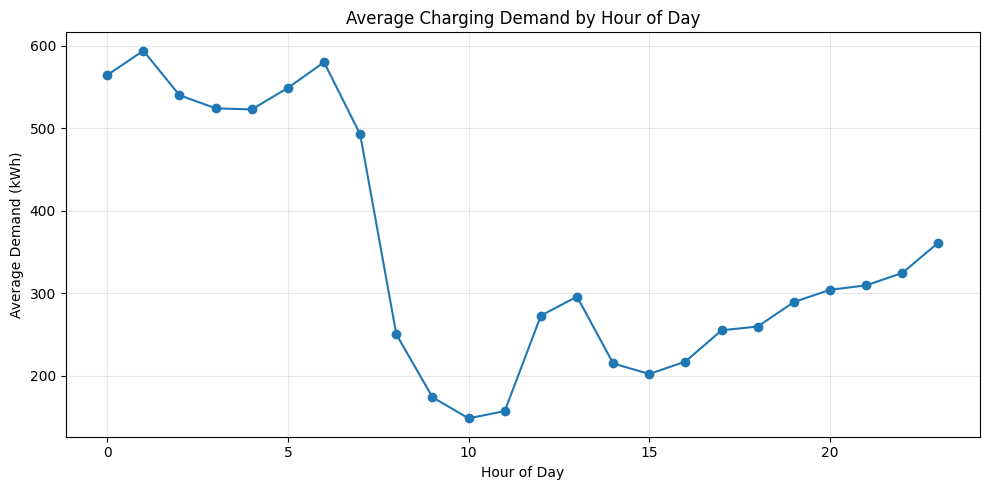

Saved plot: /kaggle/working/ev_tariff_outputs/plots/avg_demand_by_hour.png


,hour,demand_kwh
0,0,564.510440
1,1,594.126684
2,2,540.142107
3,3,524.330695
4,4,522.932603


In [15]:
# =========================
# 5C. Average demand by hour
# =========================

hourly_demand = (
    cleaned
    .groupby("hour", as_index=False)["demand_kwh"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_demand["hour"], hourly_demand["demand_kwh"], marker="o")
plt.title("Average Charging Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (kWh)")
plt.grid(True, alpha=0.3)
save_current_plot("avg_demand_by_hour.png")

display(hourly_demand.head())

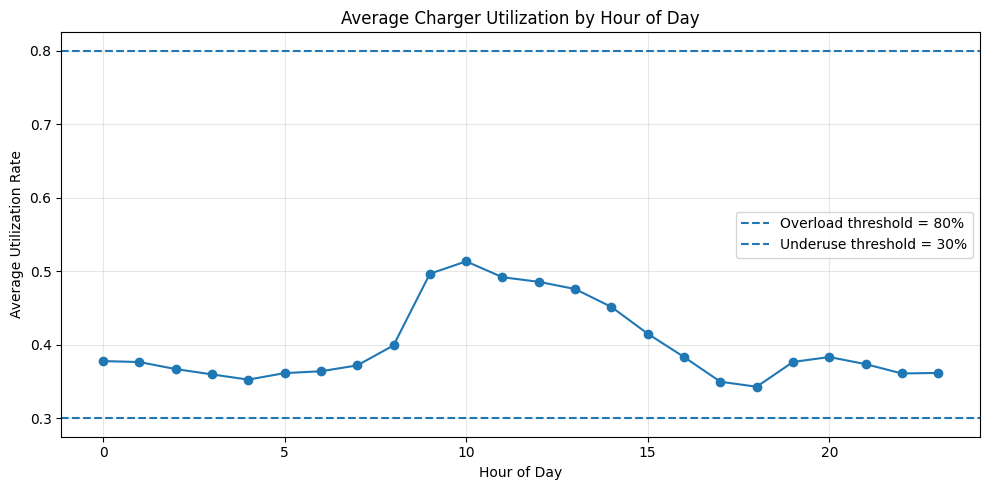

Saved plot: /kaggle/working/ev_tariff_outputs/plots/avg_utilization_by_hour.png


,hour,utilization_rate
0,0,0.377872
1,1,0.376569
2,2,0.367011
3,3,0.359778
4,4,0.352669


In [16]:
# =========================
# 5D. Average utilization by hour
# =========================

hourly_util = (
    cleaned
    .groupby("hour", as_index=False)["utilization_rate"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_util["hour"], hourly_util["utilization_rate"], marker="o")
plt.axhline(0.8, linestyle="--", label="Overload threshold = 80%")
plt.axhline(0.3, linestyle="--", label="Underuse threshold = 30%")
plt.title("Average Charger Utilization by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Utilization Rate")
plt.legend()
plt.grid(True, alpha=0.3)
save_current_plot("avg_utilization_by_hour.png")

display(hourly_util.head())

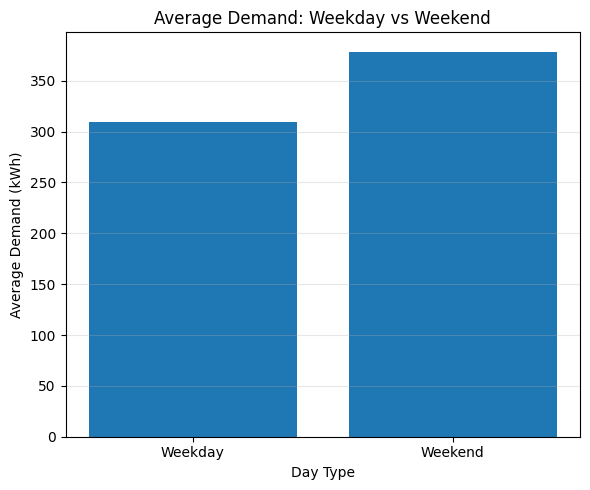

Saved plot: /kaggle/working/ev_tariff_outputs/plots/weekday_vs_weekend_demand.png


,is_weekend,demand_kwh,day_type
0,0,309.601464,Weekday
1,1,378.702283,Weekend


In [17]:
# =========================
# 5E. Weekday vs Weekend Demand
# =========================

weekend_demand = (
    cleaned
    .groupby("is_weekend", as_index=False)["demand_kwh"]
    .mean()
)

weekend_demand["day_type"] = weekend_demand["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

plt.figure(figsize=(6, 5))
plt.bar(weekend_demand["day_type"], weekend_demand["demand_kwh"])
plt.title("Average Demand: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Demand (kWh)")
plt.grid(axis="y", alpha=0.3)
save_current_plot("weekday_vs_weekend_demand.png")

display(weekend_demand)

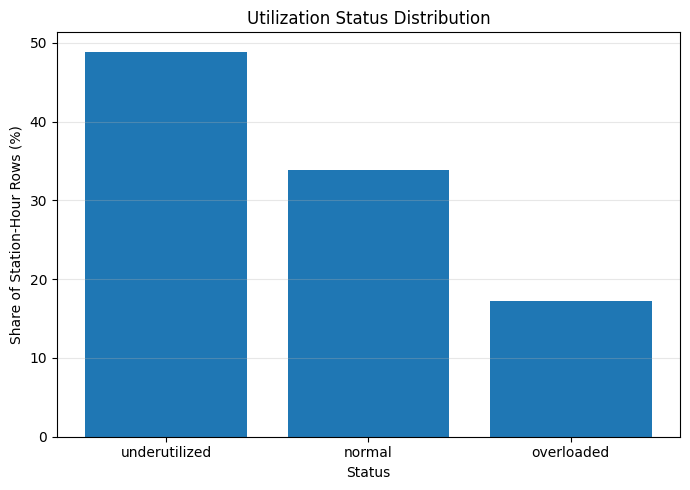

Saved plot: /kaggle/working/ev_tariff_outputs/plots/utilization_status_distribution.png


,utilization_status,percentage
0,underutilized,48.901753
1,normal,33.833100
2,overloaded,17.265147


In [18]:
# =========================
# 5F. Utilization Status Distribution
# =========================

status_counts = (
    cleaned["utilization_status"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

status_counts.columns = ["utilization_status", "percentage"]

plt.figure(figsize=(7, 5))
plt.bar(status_counts["utilization_status"], status_counts["percentage"])
plt.title("Utilization Status Distribution")
plt.xlabel("Status")
plt.ylabel("Share of Station-Hour Rows (%)")
plt.grid(axis="y", alpha=0.3)
save_current_plot("utilization_status_distribution.png")

display(status_counts)

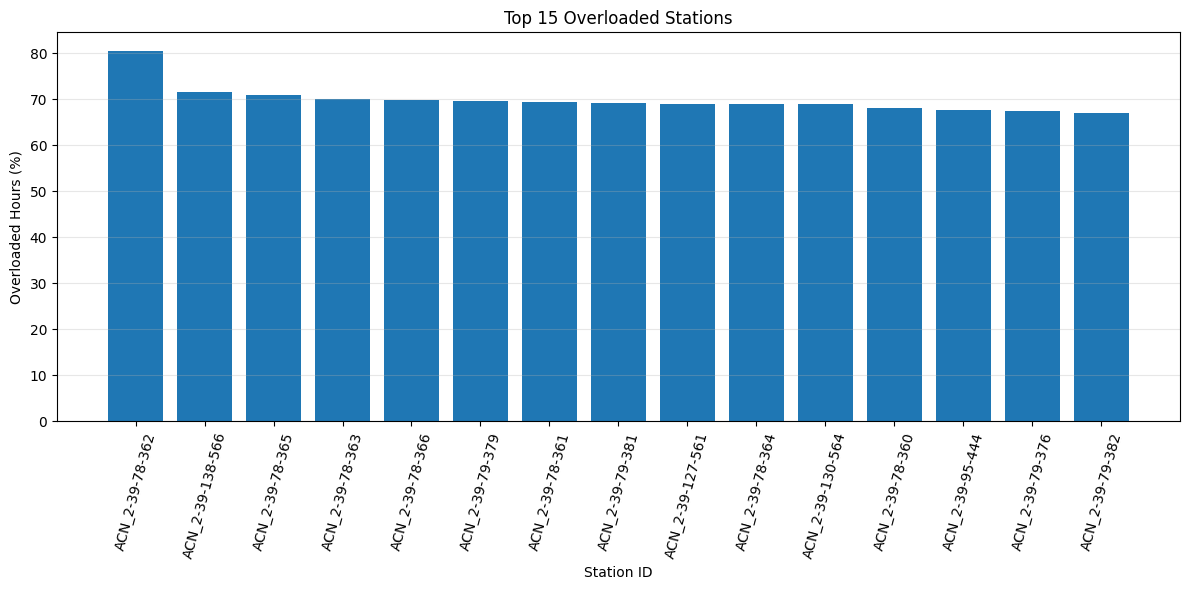

Saved plot: /kaggle/working/ev_tariff_outputs/plots/top_overloaded_stations.png


,station_id,avg_utilization,overload_share,total_demand_kwh
24,ACN_2-39-78-362,0.876634,80.484988,1880.103840
19,ACN_2-39-138-566,0.817260,71.578947,1326.533662
27,ACN_2-39-78-365,0.817507,70.819304,3487.209276
25,ACN_2-39-78-363,0.814583,70.118138,2666.999822
28,ACN_2-39-78-366,0.815878,69.865526,3280.590600
33,ACN_2-39-79-379,0.809387,69.555677,3859.160000
23,ACN_2-39-78-361,0.804875,69.455727,1911.314587
35,ACN_2-39-79-381,0.806710,69.180328,3481.174233
9,ACN_2-39-127-561,0.807000,68.956743,728.309000
26,ACN_2-39-78-364,0.803026,68.937330,1842.052250


In [19]:
# =========================
# 5G. Top Overloaded Stations
# =========================

station_overload = (
    cleaned
    .groupby("station_id")
    .agg(
        avg_utilization=("utilization_rate", "mean"),
        overload_share=("utilization_status", lambda x: (x == "overloaded").mean() * 100),
        total_demand_kwh=("demand_kwh", "sum")
    )
    .reset_index()
    .sort_values("overload_share", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
plt.bar(station_overload["station_id"].astype(str), station_overload["overload_share"])
plt.title("Top 15 Overloaded Stations")
plt.xlabel("Station ID")
plt.ylabel("Overloaded Hours (%)")
plt.xticks(rotation=75)
plt.grid(axis="y", alpha=0.3)
save_current_plot("top_overloaded_stations.png")

display(station_overload)

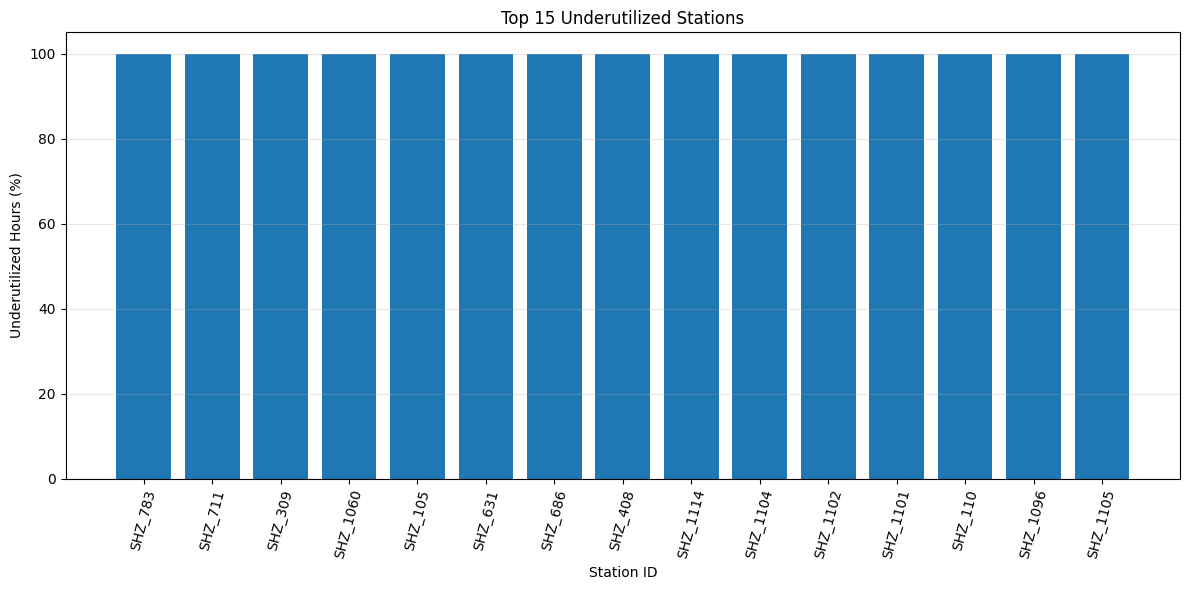

Saved plot: /kaggle/working/ev_tariff_outputs/plots/top_underutilized_stations.png


,station_id,avg_utilization,underuse_share,total_demand_kwh
252,SHZ_783,0.086892,100.0,10462.120278
230,SHZ_711,0.080406,100.0,13707.600278
153,SHZ_309,0.155830,100.0,40754.877917
67,SHZ_1060,0.077538,100.0,15597.436945
66,SHZ_105,0.149116,100.0,57509.674444
203,SHZ_631,0.089859,100.0,46570.995001
214,SHZ_686,0.086457,100.0,34621.686945
173,SHZ_408,0.126959,100.0,33988.834445
108,SHZ_1114,0.107737,100.0,42481.194028
98,SHZ_1104,0.088940,100.0,11143.821111


In [20]:
# =========================
# 5H. Top Underutilized Stations
# =========================

station_underuse = (
    cleaned
    .groupby("station_id")
    .agg(
        avg_utilization=("utilization_rate", "mean"),
        underuse_share=("utilization_status", lambda x: (x == "underutilized").mean() * 100),
        total_demand_kwh=("demand_kwh", "sum")
    )
    .reset_index()
    .sort_values("underuse_share", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
plt.bar(station_underuse["station_id"].astype(str), station_underuse["underuse_share"])
plt.title("Top 15 Underutilized Stations")
plt.xlabel("Station ID")
plt.ylabel("Underutilized Hours (%)")
plt.xticks(rotation=75)
plt.grid(axis="y", alpha=0.3)
save_current_plot("top_underutilized_stations.png")

display(station_underuse)

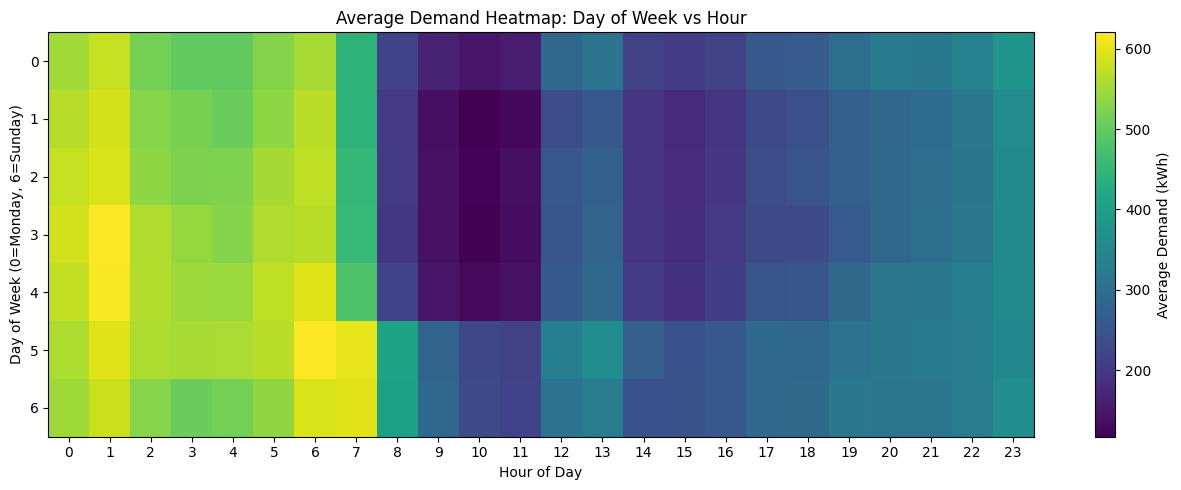

Saved plot: /kaggle/working/ev_tariff_outputs/plots/demand_heatmap_day_hour.png


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
0,550.463451,577.005697,515.942432,497.952786,496.554545,526.447690,554.347883,445.130527,218.234463,166.659672,...,216.539640,204.715778,217.360068,257.941006,263.456172,299.838727,324.939947,320.633386,338.008811,378.846012
1,565.679799,586.994623,528.954374,516.231136,504.570069,534.855294,567.999764,442.890550,200.365097,137.570384,...,192.239146,177.580108,194.019044,230.881270,240.373363,271.383537,283.435396,293.484193,316.479338,359.245024
2,575.376201,592.734107,533.994992,521.846011,522.974923,552.431341,571.556883,451.543714,201.798755,140.522887,...,193.766852,181.389136,196.678668,236.110576,248.742587,271.691489,287.730685,297.798315,310.225037,358.861292
3,586.614374,619.848226,560.484743,540.220757,526.638795,559.896168,566.739561,453.548916,199.552307,139.042402,...,195.407921,182.712200,200.746976,234.318340,234.496048,262.931633,284.687140,298.198423,316.177302,355.731901
4,574.122651,616.060823,562.337519,546.318962,544.507357,572.947981,594.840320,479.196748,218.858288,148.585063,...,206.176862,190.729061,207.887081,248.880550,251.683578,291.750779,314.383523,318.667411,331.545744,357.971452
5,558.257861,595.359786,558.732960,553.697696,557.240181,567.979843,620.345316,602.467241,407.723841,278.454059,...,269.251406,243.439544,253.755063,289.130491,287.396385,308.983413,318.012499,324.669325,329.284777,351.601196
6,548.694370,579.116251,528.935576,504.987042,515.823975,537.249755,591.813908,597.564038,402.643259,287.959677,...,244.676290,242.197366,254.717502,289.351597,291.377287,318.229716,315.632352,314.144000,328.461085,364.579532


In [21]:
# =========================
# 5I. Demand pattern by day of week and hour
# =========================

demand_heatmap = cleaned.pivot_table(
    index="day_of_week",
    columns="hour",
    values="demand_kwh",
    aggfunc="mean"
)

plt.figure(figsize=(13, 5))
plt.imshow(demand_heatmap, aspect="auto")
plt.colorbar(label="Average Demand (kWh)")
plt.title("Average Demand Heatmap: Day of Week vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Monday, 6=Sunday)")
plt.xticks(range(24))
plt.yticks(range(7))
save_current_plot("demand_heatmap_day_hour.png")

display(demand_heatmap)

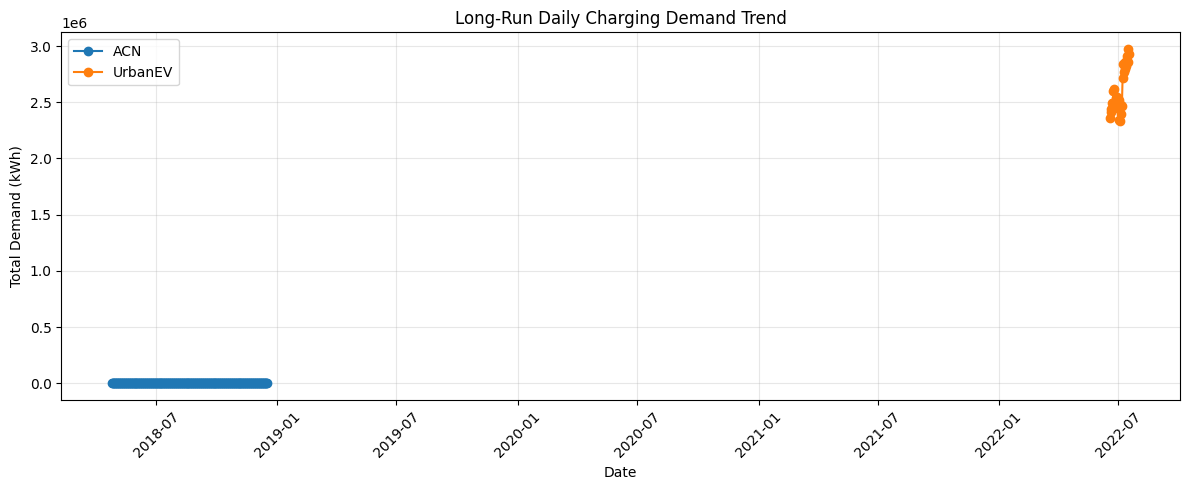

,source,date,total_demand_kwh,avg_utilization,avg_revenue
0,ACN,2018-04-25,428.539072,0.720758,32.465081
1,ACN,2018-04-26,342.736681,0.763637,26.776303
2,ACN,2018-04-27,456.675708,0.782153,32.619693
3,ACN,2018-04-28,445.423730,0.808568,47.051802
4,ACN,2018-04-29,266.006182,0.725590,45.341963


Saved: /kaggle/working/ev_tariff_outputs/daily_demand_trend.csv
Saved: /kaggle/working/ev_tariff_outputs/plots/daily_demand_trend.png


In [22]:
# =========================
# 5K. Long-run daily demand trend
# =========================

daily_trend = (
    cleaned
    .groupby(["source", "date"], as_index=False)
    .agg(
        total_demand_kwh=("demand_kwh", "sum"),
        avg_utilization=("utilization_rate", "mean"),
        avg_revenue=("revenue", "mean")
    )
)

daily_trend.to_csv(
    OUTPUT_DIR / "daily_demand_trend.csv",
    index=False
)

plt.figure(figsize=(12, 5))

for src in daily_trend["source"].dropna().unique():
    temp = daily_trend[daily_trend["source"] == src]
    plt.plot(
        temp["date"],
        temp["total_demand_kwh"],
        marker="o",
        label=src
    )

plt.title("Long-Run Daily Charging Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Demand (kWh)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "daily_demand_trend.png", dpi=160)
plt.show()

display(daily_trend.head())

print("Saved:", OUTPUT_DIR / "daily_demand_trend.csv")
print("Saved:", PLOTS_DIR / "daily_demand_trend.png")

,source,demand_period,avg_demand_kwh,std_demand_kwh,avg_utilization,std_utilization,avg_price,avg_queue_proxy
0,ACN,off_peak,2.235473,1.790896,0.773564,0.333800,15.000000,0.126952
1,ACN,peak,2.292693,1.691318,0.738157,0.324070,15.000000,0.105132
2,ACN,shoulder,2.054127,1.462278,0.826863,0.290311,15.000000,0.136719
3,UrbanEV,off_peak,555.274413,1516.301448,0.323490,0.193339,10.576714,0.001297
4,UrbanEV,peak,382.769111,1025.199343,0.262195,0.158788,11.210780,0.000409
5,UrbanEV,shoulder,353.500210,913.031534,0.242443,0.151978,11.413011,0.000229


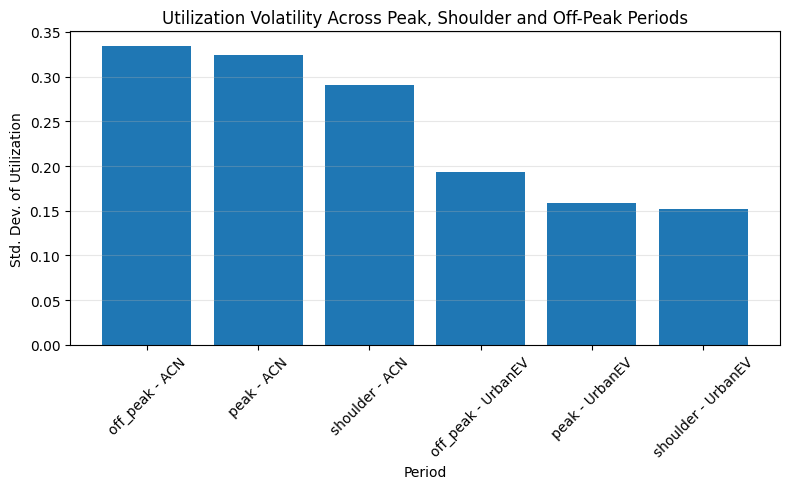

Saved: /kaggle/working/ev_tariff_outputs/peak_shoulder_offpeak_volatility.csv
Saved: /kaggle/working/ev_tariff_outputs/plots/peak_shoulder_offpeak_volatility.png


In [40]:
# =========================
# 5L. Peak / Shoulder / Off-Peak volatility analysis
# =========================

def period_label(hour):
    if 7 <= hour <= 10 or 17 <= hour <= 21:
        return "peak"
    elif 11 <= hour <= 16:
        return "shoulder"
    else:
        return "off_peak"

cleaned["demand_period"] = cleaned["hour"].apply(period_label)

period_volatility = (
    cleaned
    .groupby(["source", "demand_period"], as_index=False)
    .agg(
        avg_demand_kwh=("demand_kwh", "mean"),
        std_demand_kwh=("demand_kwh", "std"),
        avg_utilization=("utilization_rate", "mean"),
        std_utilization=("utilization_rate", "std"),
        avg_price=("average_price", "mean"),
        avg_queue_proxy=("queue_proxy", "mean")
    )
)

period_volatility.to_csv(
    OUTPUT_DIR / "peak_shoulder_offpeak_volatility.csv",
    index=False
)

display(period_volatility)

plt.figure(figsize=(8, 5))
plt.bar(
    period_volatility["demand_period"].astype(str) + " - " + period_volatility["source"].astype(str),
    period_volatility["std_utilization"]
)
plt.title("Utilization Volatility Across Peak, Shoulder and Off-Peak Periods")
plt.xlabel("Period")
plt.ylabel("Std. Dev. of Utilization")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "peak_shoulder_offpeak_volatility.png", dpi=160)
plt.show()

print("Saved:", OUTPUT_DIR / "peak_shoulder_offpeak_volatility.csv")
print("Saved:", PLOTS_DIR / "peak_shoulder_offpeak_volatility.png")

Adjacency shape: (247, 248)
Distance shape: (247, 248)


,adjacency_rows,adjacency_cols,distance_rows,distance_cols,adjacency_nonzero_connections,avg_distance,median_distance,max_distance
0,247,248,247,247,1500,0.035695,0.0,17.424083


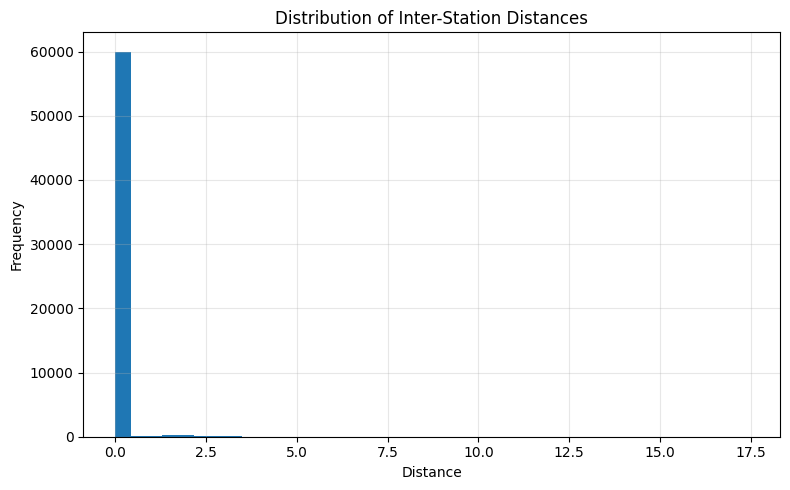

Saved: /kaggle/working/ev_tariff_outputs/spatial_network_summary.csv
Saved: /kaggle/working/ev_tariff_outputs/plots/distance_distribution.png


In [41]:
# =========================
# 5M. Spatial network analysis using adjacency and distance files
# =========================

adj = pd.read_csv(FILES["adj"])
distance = pd.read_csv(FILES["distance"])

print("Adjacency shape:", adj.shape)
print("Distance shape:", distance.shape)

# Drop unnamed index columns if present
adj = adj.drop(columns=[c for c in adj.columns if str(c).lower().startswith("unnamed")], errors="ignore")
distance = distance.drop(columns=[c for c in distance.columns if str(c).lower().startswith("unnamed")], errors="ignore")

# Basic spatial summaries
adj_values = adj.select_dtypes(include=[np.number]).values.flatten()
distance_values = distance.select_dtypes(include=[np.number]).values.flatten()

adj_values = adj_values[~np.isnan(adj_values)]
distance_values = distance_values[~np.isnan(distance_values)]

spatial_summary = {
    "adjacency_rows": adj.shape[0],
    "adjacency_cols": adj.shape[1],
    "distance_rows": distance.shape[0],
    "distance_cols": distance.shape[1],
    "adjacency_nonzero_connections": int((adj_values > 0).sum()),
    "avg_distance": float(np.mean(distance_values)) if len(distance_values) > 0 else np.nan,
    "median_distance": float(np.median(distance_values)) if len(distance_values) > 0 else np.nan,
    "max_distance": float(np.max(distance_values)) if len(distance_values) > 0 else np.nan
}

spatial_summary_df = pd.DataFrame([spatial_summary])

spatial_summary_df.to_csv(
    OUTPUT_DIR / "spatial_network_summary.csv",
    index=False
)

display(spatial_summary_df)

# Distance distribution plot
plt.figure(figsize=(8, 5))
plt.hist(distance_values, bins=40)
plt.title("Distribution of Inter-Station Distances")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "distance_distribution.png", dpi=160)
plt.show()

print("Saved:", OUTPUT_DIR / "spatial_network_summary.csv")
print("Saved:", PLOTS_DIR / "distance_distribution.png")

## 6. Demand Prediction Agent

The Demand Prediction Agent forecasts **next-hour utilization**.

Target:
`target_next_hour_utilization`

Features:
- temporal: hour, day_of_week, weekend, month
- station metadata: capacity, fast/slow count, area, CBD
- lag features: previous utilization, demand, occupancy, price
- rolling features: 3-hour and 6-hour averages

In [23]:
# =========================
# 6. Strong Feature Engineering for High-Accuracy ML
# =========================

df = cleaned.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# --------------------------------------------------
# IMPORTANT:
# For high-quality forecasting, use UrbanEV for ML.
# ACN is session-level and sparse, UrbanEV is dense time-series.
# --------------------------------------------------
ml_source = "UrbanEV"

df = df[df["source"] == ml_source].copy()

df = df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

# Temporal features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["date"] = df["timestamp"].dt.date

# Cyclic features
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Ensure metadata columns exist
metadata_cols = [
    "fast_count",
    "slow_count",
    "area",
    "CBD",
    "dynamic_pricing",
    "station_capacity",
    "longitude",
    "latitude"
]

for col in metadata_cols:
    if col not in df.columns:
        df[col] = 0

# Clean metadata
for col in [
    "fast_count",
    "slow_count",
    "CBD",
    "dynamic_pricing",
    "station_capacity",
    "longitude",
    "latitude"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["area"] = df["area"].fillna("unknown").astype(str)

# Core numeric series
base_series = [
    "utilization_rate",
    "demand_kwh",
    "occupancy_count",
    "average_price",
    "queue_proxy"
]

for col in base_series:
    if col not in df.columns:
        df[col] = 0
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

group = df.groupby("station_id", group_keys=False)

# --------------------------------------------------
# Lag features
# Since data is hourly:
# lag_1  = previous hour
# lag_24 = same hour yesterday
# lag_48 = same hour two days ago
# lag_72 = same hour three days ago
# --------------------------------------------------

lags = [1, 2, 3, 6, 12, 24, 25, 48, 72]
rolling_windows = [3, 6, 12, 24, 48]

for col in base_series:
    for lag in lags:
        df[f"{col}_lag_{lag}"] = group[col].shift(lag)

    for window in rolling_windows:
        df[f"{col}_rolling_mean_{window}"] = group[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).mean()
        )

        df[f"{col}_rolling_std_{window}"] = group[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).std()
        )

        df[f"{col}_rolling_min_{window}"] = group[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).min()
        )

        df[f"{col}_rolling_max_{window}"] = group[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).max()
        )

# --------------------------------------------------
# Historical station behavior features
# --------------------------------------------------

df["station_mean_utilization_past"] = group["utilization_rate"].transform(
    lambda s: s.shift(1).expanding().mean()
)

df["station_mean_demand_past"] = group["demand_kwh"].transform(
    lambda s: s.shift(1).expanding().mean()
)

df["station_mean_occupancy_past"] = group["occupancy_count"].transform(
    lambda s: s.shift(1).expanding().mean()
)

# --------------------------------------------------
# Station-hour pattern features
# These are very powerful because station behavior repeats by hour.
# Use shift(1) to avoid direct leakage from current target row.
# --------------------------------------------------

df["station_hour_mean_utilization"] = (
    df.groupby(["station_id", "hour"])["utilization_rate"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

df["station_hour_mean_demand"] = (
    df.groupby(["station_id", "hour"])["demand_kwh"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

df["station_dow_hour_mean_utilization"] = (
    df.groupby(["station_id", "day_of_week", "hour"])["utilization_rate"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

df["station_dow_hour_mean_demand"] = (
    df.groupby(["station_id", "day_of_week", "hour"])["demand_kwh"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

# --------------------------------------------------
# Network-level context
# This captures system-wide congestion/load pattern.
# Use timestamp-level aggregates.
# --------------------------------------------------

network = (
    df.groupby("timestamp")
    .agg(
        network_avg_utilization=("utilization_rate", "mean"),
        network_total_demand=("demand_kwh", "sum"),
        network_avg_occupancy=("occupancy_count", "mean"),
        network_avg_price=("average_price", "mean")
    )
    .reset_index()
)

network = network.sort_values("timestamp")

for col in [
    "network_avg_utilization",
    "network_total_demand",
    "network_avg_occupancy",
    "network_avg_price"
]:
    network[f"{col}_lag_1"] = network[col].shift(1)
    network[f"{col}_lag_24"] = network[col].shift(24)
    network[f"{col}_rolling_24"] = network[col].shift(1).rolling(24, min_periods=1).mean()

# Keep only shifted network features to avoid leakage
network_features = [
    "timestamp",
    "network_avg_utilization_lag_1",
    "network_avg_utilization_lag_24",
    "network_avg_utilization_rolling_24",
    "network_total_demand_lag_1",
    "network_total_demand_lag_24",
    "network_total_demand_rolling_24",
    "network_avg_occupancy_lag_1",
    "network_avg_occupancy_lag_24",
    "network_avg_occupancy_rolling_24",
    "network_avg_price_lag_1",
    "network_avg_price_lag_24",
    "network_avg_price_rolling_24"
]

df = df.merge(network[network_features], on="timestamp", how="left")

# --------------------------------------------------
# Target
# --------------------------------------------------

df["target_next_hour_utilization"] = group["utilization_rate"].shift(-1)

# Fill rolling std missing
for col in df.columns:
    if "rolling_std" in col:
        df[col] = df[col].fillna(0)

# Feature columns
feature_cols = [
    "source",
    "site",
    "station_id",
    "area",

    "hour",
    "day_of_week",
    "is_weekend",
    "month",
    "day",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    "station_capacity",
    "fast_count",
    "slow_count",
    "CBD",
    "dynamic_pricing",
    "longitude",
    "latitude",

    # current known state
    "utilization_rate",
    "demand_kwh",
    "occupancy_count",
    "average_price",
    "queue_proxy",

    # station historical behavior
    "station_mean_utilization_past",
    "station_mean_demand_past",
    "station_mean_occupancy_past",
    "station_hour_mean_utilization",
    "station_hour_mean_demand",
    "station_dow_hour_mean_utilization",
    "station_dow_hour_mean_demand",
]

# Add generated lag/rolling/network features
for col in df.columns:
    if (
        "_lag_" in col or
        "_rolling_mean_" in col or
        "_rolling_std_" in col or
        "_rolling_min_" in col or
        "_rolling_max_" in col or
        col.startswith("network_")
    ):
        if col not in feature_cols:
            feature_cols.append(col)

feature_cols = list(dict.fromkeys(feature_cols))

model_df = df.dropna(subset=feature_cols + ["target_next_hour_utilization"]).copy()

model_df = model_df[
    (model_df["target_next_hour_utilization"] >= 0) &
    (model_df["target_next_hour_utilization"] <= 1)
].copy()

print("Model dataframe shape:", model_df.shape)
print("Number of features:", len(feature_cols))
display(model_df[feature_cols + ["target_next_hour_utilization"]].head())

Model dataframe shape: (136097, 201)
Number of features: 189


,source,site,station_id,area,hour,day_of_week,is_weekend,month,day,hour_sin,...,network_total_demand_lag_1,network_total_demand_lag_24,network_total_demand_rolling_24,network_avg_occupancy_lag_1,network_avg_occupancy_lag_24,network_avg_occupancy_rolling_24,network_avg_price_lag_1,network_avg_price_lag_24,network_avg_price_rolling_24,target_next_hour_utilization
168,UrbanEV,Shenzhen,SHZ_1000,3.08,0,6,1,6,26,0.000000,...,89758.872501,147744.790140,109125.154514,23.244265,26.074899,22.494250,10.791715,10.436136,10.982311,0.347150
169,UrbanEV,Shenzhen,SHZ_1000,3.08,1,6,1,6,26,0.258819,...,144911.008333,160756.768473,109007.080272,24.984818,26.525978,22.448830,10.436136,10.436136,10.982311,0.347150
170,UrbanEV,Shenzhen,SHZ_1000,3.08,2,6,1,6,26,0.500000,...,154635.391667,148108.957778,108752.022905,25.406208,26.238866,22.402173,10.436136,10.436136,10.982311,0.344560
171,UrbanEV,Shenzhen,SHZ_1000,3.08,3,6,1,6,26,0.707107,...,133673.816666,144599.982361,108150.558692,24.835358,26.171053,22.343694,10.436136,10.436136,10.982311,0.341969
172,UrbanEV,Shenzhen,SHZ_1000,3.08,4,6,1,6,26,0.866025,...,126753.711945,145810.686528,107406.964092,24.640013,26.139001,22.279900,10.436136,10.436136,10.982311,0.341969


In [24]:
# =========================
# 7. Better time-based split
# =========================

model_df = model_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

model_df["split"] = "train"

# Split per station, not globally
for station, sub in model_df.groupby("station_id"):
    cutoff = sub["timestamp"].quantile(0.8)

    model_df.loc[
        (model_df["station_id"] == station) &
        (model_df["timestamp"] > cutoff),
        "split"
    ] = "test"

train_df = model_df[model_df["split"] == "train"].copy()
test_df = model_df[model_df["split"] == "test"].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

MAX_TRAIN_ROWS = 160000

if len(train_df) > MAX_TRAIN_ROWS:
    train_sample = train_df.sample(MAX_TRAIN_ROWS, random_state=42)
else:
    train_sample = train_df.copy()

X_train = train_sample[feature_cols]
y_train = train_sample["target_next_hour_utilization"]

X_test = test_df[feature_cols]
y_test = test_df["target_next_hour_utilization"]

cat_cols = ["source", "site", "station_id", "area"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols
        ),
        (
            "num",
            "passthrough",
            num_cols
        )
    ]
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Train rows: 108927
Test rows: 27170
X_train: (108927, 189)
X_test: (27170, 189)


In [25]:
# =========================
# 8. High-Accuracy Demand Prediction Agent
# =========================

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Random Forest Strong": RandomForestRegressor(
        n_estimators=300,
        max_depth=30,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    ),

    "Extra Trees Strong": ExtraTreesRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.04,
        max_leaf_nodes=63,
        l2_regularization=0.001,
        random_state=42
    )
}

results = []
trained_models = {}

for model_name, model in models.items():
    print(f"\nTraining: {model_name}")

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    pred = np.clip(pred, 0, 1)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[model_name] = pipe

model_results = pd.DataFrame(results).sort_values("RMSE")
model_results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)

display(model_results)

best_model_name = model_results.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)


Training: Random Forest Strong

Training: Extra Trees Strong

Training: Hist Gradient Boosting


,model,MAE,RMSE,R2
2,Hist Gradient Boosting,0.021926,0.036240,0.956705
0,Random Forest Strong,0.027737,0.044427,0.934933
1,Extra Trees Strong,0.030716,0.047391,0.925963


Best model: Hist Gradient Boosting


In [26]:
# =========================
# 8A. Save high-accuracy predictions
# =========================

test_predictions = test_df.copy()

test_predictions["predicted_utilization"] = np.clip(
    best_model.predict(X_test),
    0,
    1
)

test_predictions.to_csv(
    OUTPUT_DIR / "predicted_utilization.csv",
    index=False
)

display(
    test_predictions[
        [
            "station_id",
            "site",
            "source",
            "timestamp",
            "utilization_rate",
            "target_next_hour_utilization",
            "predicted_utilization"
        ]
    ].head()
)

print("Saved:", OUTPUT_DIR / "predicted_utilization.csv")

,station_id,site,source,timestamp,utilization_rate,target_next_hour_utilization,predicted_utilization
441,SHZ_1000,Shenzhen,UrbanEV,2022-07-14 09:00:00,0.155440,0.148100,0.142074
442,SHZ_1000,Shenzhen,UrbanEV,2022-07-14 10:00:00,0.148100,0.151123,0.148868
443,SHZ_1000,Shenzhen,UrbanEV,2022-07-14 11:00:00,0.151123,0.155440,0.155295
444,SHZ_1000,Shenzhen,UrbanEV,2022-07-14 12:00:00,0.155440,0.168394,0.158729
445,SHZ_1000,Shenzhen,UrbanEV,2022-07-14 13:00:00,0.168394,0.174870,0.172635


Saved: /kaggle/working/ev_tariff_outputs/predicted_utilization.csv


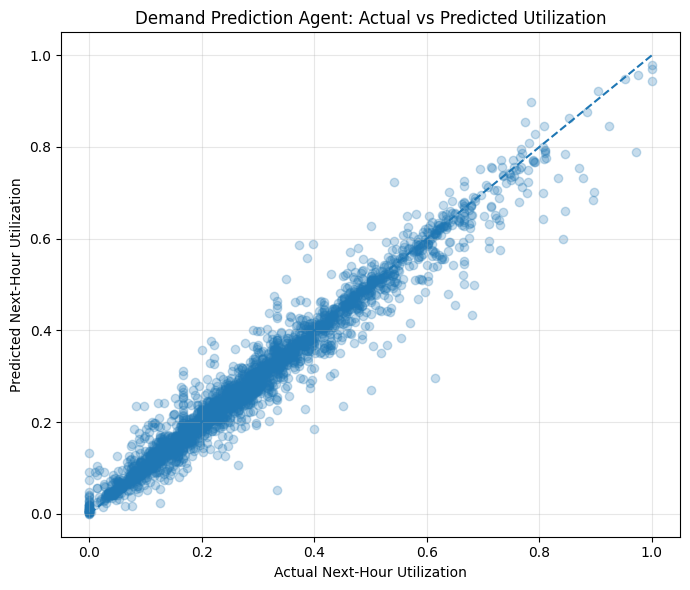

Saved plot: /kaggle/working/ev_tariff_outputs/plots/actual_vs_predicted_utilization.png


In [27]:
# =========================
# 8B. Actual vs Predicted Utilization Plot
# =========================

plot_sample = test_predictions.sample(
    min(3000, len(test_predictions)),
    random_state=42
)

plt.figure(figsize=(7, 6))

plt.scatter(
    plot_sample["target_next_hour_utilization"],
    plot_sample["predicted_utilization"],
    alpha=0.25
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Demand Prediction Agent: Actual vs Predicted Utilization")
plt.xlabel("Actual Next-Hour Utilization")
plt.ylabel("Predicted Next-Hour Utilization")
plt.grid(True, alpha=0.3)

save_current_plot("actual_vs_predicted_utilization.png")

In [43]:
test_predictions.to_csv(
    OUTPUT_DIR / "predicted_utilization.csv",
    index=False
)

In [44]:
# =========================
# 8C. Additional Demand Prediction Agent outputs
# =========================

# Use predicted utilization as congestion probability proxy.
# Higher predicted utilization means higher congestion risk.
test_predictions["congestion_probability"] = test_predictions["predicted_utilization"].clip(0, 1)

# Expected charging load:
# If rolling demand feature exists, use it as expected load estimate.
# Otherwise use current demand_kwh as scenario load estimate.
if "demand_kwh_rolling_mean_24" in test_predictions.columns:
    test_predictions["expected_charging_load_kwh"] = test_predictions["demand_kwh_rolling_mean_24"]
elif "demand_kwh_lag_24" in test_predictions.columns:
    test_predictions["expected_charging_load_kwh"] = test_predictions["demand_kwh_lag_24"]
else:
    test_predictions["expected_charging_load_kwh"] = test_predictions["demand_kwh"]

test_predictions.to_csv(
    OUTPUT_DIR / "predicted_utilization.csv",
    index=False
)

display(
    test_predictions[
        [
            "station_id",
            "timestamp",
            "predicted_utilization",
            "congestion_probability",
            "expected_charging_load_kwh"
        ]
    ].head()
)

print("Updated:", OUTPUT_DIR / "predicted_utilization.csv")

,station_id,timestamp,predicted_utilization,congestion_probability,expected_charging_load_kwh
441,SHZ_1000,2022-07-14 09:00:00,0.142074,0.142074,247.887459
442,SHZ_1000,2022-07-14 10:00:00,0.148868,0.148868,246.021522
443,SHZ_1000,2022-07-14 11:00:00,0.155295,0.155295,245.110347
444,SHZ_1000,2022-07-14 12:00:00,0.158729,0.158729,244.246285
445,SHZ_1000,2022-07-14 13:00:00,0.172635,0.172635,242.945937


Updated: /kaggle/working/ev_tariff_outputs/predicted_utilization.csv


## 7. Tariff Pricing Agent

The Tariff Pricing Agent converts predicted utilization into a dynamic tariff.

Rules:
- predicted utilization > 80% → surge tariff
- predicted utilization < 30% → mild discount signal
- otherwise → normal tariff around baseline

We use bounded pricing to avoid unrealistic tariffs.

In [28]:
# =========================
# 9. Tariff Pricing Agent
# =========================

pred_df = test_predictions.copy()

BASE_TARIFF = 15.0
MIN_TARIFF = 14.5
MAX_TARIFF = 25.0

u = pred_df["predicted_utilization"]

# Revenue-aware pricing:
# - Strong surge during congestion
# - Very mild discount during low utilization
# - Slight adjustment during normal utilization
tariff = np.where(
    u > 0.80,
    BASE_TARIFF * (1.45 + 1.50 * (u - 0.80)),
    np.where(
        u < 0.30,
        BASE_TARIFF * (1 - 0.02 * (0.30 - u)),
        BASE_TARIFF * (1 + 0.05 * (u - 0.60))
    )
)

pred_df["recommended_tariff"] = np.clip(
    tariff,
    MIN_TARIFF,
    MAX_TARIFF
)

pred_df["pricing_action"] = np.select(
    [
        pred_df["predicted_utilization"] > 0.80,
        pred_df["predicted_utilization"] < 0.30
    ],
    [
        "SURGE",
        "DISCOUNT"
    ],
    default="NORMAL"
)

display(
    pred_df[
        [
            "station_id",
            "timestamp",
            "predicted_utilization",
            "recommended_tariff",
            "pricing_action"
        ]
    ].head()
)

,station_id,timestamp,predicted_utilization,recommended_tariff,pricing_action
441,SHZ_1000,2022-07-14 09:00:00,0.142074,14.952622,DISCOUNT
442,SHZ_1000,2022-07-14 10:00:00,0.148868,14.954660,DISCOUNT
443,SHZ_1000,2022-07-14 11:00:00,0.155295,14.956588,DISCOUNT
444,SHZ_1000,2022-07-14 12:00:00,0.158729,14.957619,DISCOUNT
445,SHZ_1000,2022-07-14 13:00:00,0.172635,14.961791,DISCOUNT


## 8. Revenue and congestion simulation

Because we do not observe real customer behavior after tariff changes, we simulate short-run response with a mild elasticity assumption.

Important: this is a **scenario simulation**, not a causal claim.

Elasticity assumption:
- EV charging is relatively inelastic in the short run.
- If price increases, demand slightly decreases.
- If price decreases, demand slightly increases.

In [29]:
# =========================
# 10. Pricing simulation
# =========================

ELASTICITY = -0.05

pred_df["baseline_tariff"] = BASE_TARIFF

pred_df["price_change_pct"] = (
    pred_df["recommended_tariff"] - pred_df["baseline_tariff"]
) / pred_df["baseline_tariff"]

# Demand response:
# If price increases, demand slightly decreases.
# If price decreases, demand slightly increases.
pred_df["adjusted_demand_kwh"] = (
    pred_df["demand_kwh"] *
    (1 + ELASTICITY * pred_df["price_change_pct"])
).clip(lower=0)

pred_df["baseline_revenue"] = (
    pred_df["demand_kwh"] *
    pred_df["baseline_tariff"]
)

pred_df["dynamic_revenue"] = (
    pred_df["adjusted_demand_kwh"] *
    pred_df["recommended_tariff"]
)

# Simulated utilization response
pred_df["simulated_utilization_after_pricing"] = (
    pred_df["predicted_utilization"] *
    (1 + ELASTICITY * pred_df["price_change_pct"])
).clip(0, 1)

# Congestion proxy before and after
pred_df["queue_proxy_before"] = (
    pred_df["predicted_utilization"] - 0.80
).clip(lower=0)

pred_df["queue_proxy_after"] = (
    pred_df["simulated_utilization_after_pricing"] - 0.80
).clip(lower=0)

pred_df["queue_proxy_reduction"] = (
    pred_df["queue_proxy_before"] -
    pred_df["queue_proxy_after"]
)

# Save final tariff recommendations
pred_df.to_csv(
    OUTPUT_DIR / "dynamic_tariff_recommendations.csv",
    index=False
)

display(
    pred_df[
        [
            "station_id",
            "timestamp",
            "predicted_utilization",
            "recommended_tariff",
            "pricing_action",
            "baseline_revenue",
            "dynamic_revenue",
            "queue_proxy_before",
            "queue_proxy_after",
            "queue_proxy_reduction"
        ]
    ].head()
)

print("Saved:", OUTPUT_DIR / "dynamic_tariff_recommendations.csv")

,station_id,timestamp,predicted_utilization,recommended_tariff,pricing_action,baseline_revenue,dynamic_revenue,queue_proxy_before,queue_proxy_after,queue_proxy_reduction
441,SHZ_1000,2022-07-14 09:00:00,0.142074,14.952622,DISCOUNT,1882.737500,1877.087236,0.0,0.0,0.0
442,SHZ_1000,2022-07-14 10:00:00,0.148868,14.954660,DISCOUNT,1732.368750,1727.393441,0.0,0.0,0.0
443,SHZ_1000,2022-07-14 11:00:00,0.155295,14.956588,DISCOUNT,1750.029167,1745.216897,0.0,0.0,0.0
444,SHZ_1000,2022-07-14 12:00:00,0.158729,14.957619,DISCOUNT,1813.729167,1808.860129,0.0,0.0,0.0
445,SHZ_1000,2022-07-14 13:00:00,0.172635,14.961791,DISCOUNT,2041.841666,2036.899889,0.0,0.0,0.0


Saved: /kaggle/working/ev_tariff_outputs/dynamic_tariff_recommendations.csv


In [30]:
# =========================
# 10A. Pricing metrics summary
# =========================

baseline_total_revenue = pred_df["baseline_revenue"].sum()
dynamic_total_revenue = pred_df["dynamic_revenue"].sum()

revenue_gain_pct = (
    (dynamic_total_revenue - baseline_total_revenue)
    / baseline_total_revenue * 100
    if baseline_total_revenue > 0 else 0
)

queue_before = pred_df["queue_proxy_before"].sum()
queue_after = pred_df["queue_proxy_after"].sum()

queue_proxy_reduction_pct = (
    (queue_before - queue_after) / queue_before * 100
    if queue_before > 0 else 0
)

avg_tariff = pred_df["recommended_tariff"].mean()

pricing_efficiency_baseline = (
    pred_df["baseline_revenue"].sum() / pred_df["demand_kwh"].sum()
    if pred_df["demand_kwh"].sum() > 0 else 0
)

pricing_efficiency_dynamic = (
    pred_df["dynamic_revenue"].sum() / pred_df["adjusted_demand_kwh"].sum()
    if pred_df["adjusted_demand_kwh"].sum() > 0 else 0
)

pricing_summary = {
    "baseline_total_revenue": baseline_total_revenue,
    "dynamic_total_revenue": dynamic_total_revenue,
    "revenue_gain_pct": revenue_gain_pct,
    "queue_proxy_before": queue_before,
    "queue_proxy_after": queue_after,
    "queue_proxy_reduction_pct": queue_proxy_reduction_pct,
    "average_recommended_tariff": avg_tariff,
    "pricing_efficiency_baseline": pricing_efficiency_baseline,
    "pricing_efficiency_dynamic": pricing_efficiency_dynamic,
    "surge_share_pct": pred_df["pricing_action"].eq("SURGE").mean() * 100,
    "discount_share_pct": pred_df["pricing_action"].eq("DISCOUNT").mean() * 100,
    "normal_share_pct": pred_df["pricing_action"].eq("NORMAL").mean() * 100,
}

pricing_summary_df = pd.DataFrame([pricing_summary])

pricing_summary_df.to_csv(
    OUTPUT_DIR / "pricing_summary.csv",
    index=False
)

display(pricing_summary_df)

,baseline_total_revenue,dynamic_total_revenue,revenue_gain_pct,queue_proxy_before,queue_proxy_after,queue_proxy_reduction_pct,average_recommended_tariff,pricing_efficiency_baseline,pricing_efficiency_dynamic,surge_share_pct,discount_share_pct,normal_share_pct
0,1.951319e+08,1.953831e+08,0.128699,11.796038,8.25999,29.976573,14.980478,15.0,15.02044,0.581524,59.698197,39.72028


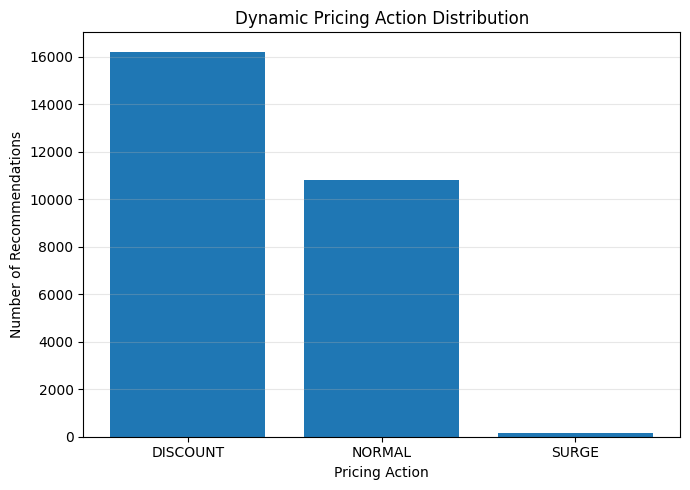

Saved: /kaggle/working/ev_tariff_outputs/plots/pricing_action_distribution.png


In [31]:
# =========================
# 10B. Pricing action distribution
# =========================

action_counts = pred_df["pricing_action"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(action_counts.index.astype(str), action_counts.values)
plt.title("Dynamic Pricing Action Distribution")
plt.xlabel("Pricing Action")
plt.ylabel("Number of Recommendations")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "pricing_action_distribution.png", dpi=160)
plt.show()

print("Saved:", PLOTS_DIR / "pricing_action_distribution.png")

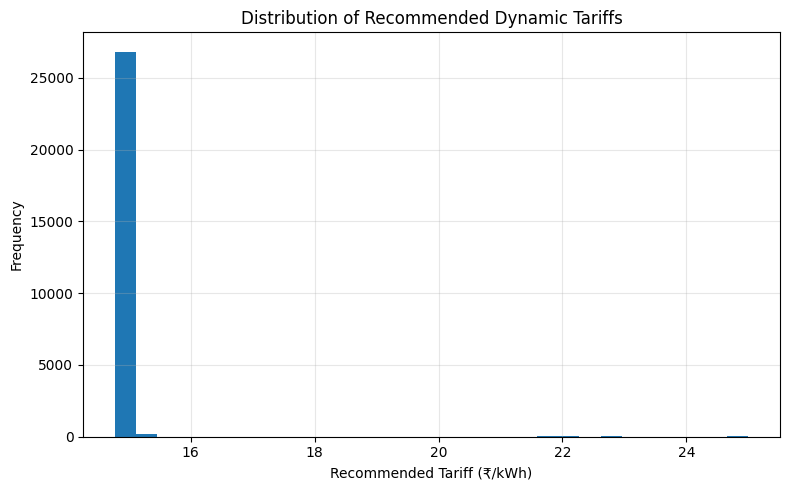

Saved: /kaggle/working/ev_tariff_outputs/plots/recommended_tariff_distribution.png


In [32]:
# =========================
# 10C. Recommended tariff distribution
# =========================

plt.figure(figsize=(8, 5))
plt.hist(pred_df["recommended_tariff"], bins=30)
plt.title("Distribution of Recommended Dynamic Tariffs")
plt.xlabel("Recommended Tariff (₹/kWh)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "recommended_tariff_distribution.png", dpi=160)
plt.show()

print("Saved:", PLOTS_DIR / "recommended_tariff_distribution.png")

## 9. Monitoring & Learning Agent

The Monitoring Agent compares predicted and actual utilization. Then it adjusts the pricing sensitivity parameter.

Simple rule:
- If actual utilization remains above 85%, increase surge sensitivity.
- If actual utilization falls below 25%, reduce pricing sensitivity.
- Otherwise, keep sensitivity unchanged.

This creates a transparent feedback loop.

In [33]:
# =========================
# 11. Monitoring & Learning Agent
# =========================

monitoring_log = pred_df.copy()

# In our dataset, actual next-hour utilization is the target column.
# Rename it for clearer monitoring-agent language.
if "actual_next_hour_utilization" not in monitoring_log.columns:
    monitoring_log["actual_next_hour_utilization"] = monitoring_log["target_next_hour_utilization"]

# Prediction error
monitoring_log["prediction_error"] = (
    monitoring_log["actual_next_hour_utilization"] -
    monitoring_log["predicted_utilization"]
)

monitoring_log["absolute_prediction_error"] = monitoring_log["prediction_error"].abs()

# Initial pricing sensitivity
ALPHA_START = 0.85

monitoring_log["alpha_before"] = ALPHA_START

# Learning rule:
# If actual utilization remains too high, increase pricing sensitivity.
# If actual utilization becomes too low, reduce pricing sensitivity.
monitoring_log["alpha_adjustment"] = np.select(
    [
        monitoring_log["actual_next_hour_utilization"] > 0.85,
        monitoring_log["actual_next_hour_utilization"] < 0.25
    ],
    [
        0.05,
        -0.05
    ],
    default=0.0
)

monitoring_log["alpha_after"] = (
    monitoring_log["alpha_before"] +
    monitoring_log["alpha_adjustment"]
).clip(0.3, 1.5)

# Pricing efficiency
monitoring_log["baseline_pricing_efficiency"] = (
    monitoring_log["baseline_revenue"] /
    monitoring_log["demand_kwh"].replace(0, np.nan)
)

monitoring_log["dynamic_pricing_efficiency"] = (
    monitoring_log["dynamic_revenue"] /
    monitoring_log["adjusted_demand_kwh"].replace(0, np.nan)
)

monitoring_log["pricing_efficiency_gain"] = (
    monitoring_log["dynamic_pricing_efficiency"] -
    monitoring_log["baseline_pricing_efficiency"]
)

monitoring_cols = [
    "station_id",
    "source",
    "timestamp",
    "predicted_utilization",
    "actual_next_hour_utilization",
    "prediction_error",
    "absolute_prediction_error",
    "recommended_tariff",
    "pricing_action",
    "baseline_revenue",
    "dynamic_revenue",
    "queue_proxy_before",
    "queue_proxy_after",
    "queue_proxy_reduction",
    "alpha_before",
    "alpha_adjustment",
    "alpha_after",
    "baseline_pricing_efficiency",
    "dynamic_pricing_efficiency",
    "pricing_efficiency_gain"
]

# Keep only columns that exist
monitoring_cols = [col for col in monitoring_cols if col in monitoring_log.columns]

monitoring_log[monitoring_cols].to_csv(
    OUTPUT_DIR / "monitoring_agent_log.csv",
    index=False
)

display(monitoring_log[monitoring_cols].head())

print("Saved:", OUTPUT_DIR / "monitoring_agent_log.csv")

,station_id,source,timestamp,predicted_utilization,actual_next_hour_utilization,prediction_error,absolute_prediction_error,recommended_tariff,pricing_action,baseline_revenue,dynamic_revenue,queue_proxy_before,queue_proxy_after,queue_proxy_reduction,alpha_before,alpha_adjustment,alpha_after,baseline_pricing_efficiency,dynamic_pricing_efficiency,pricing_efficiency_gain
441,SHZ_1000,UrbanEV,2022-07-14 09:00:00,0.142074,0.148100,0.006026,0.006026,14.952622,DISCOUNT,1882.737500,1877.087236,0.0,0.0,0.0,0.85,-0.05,0.8,15.0,14.952622,-0.047378
442,SHZ_1000,UrbanEV,2022-07-14 10:00:00,0.148868,0.151123,0.002255,0.002255,14.954660,DISCOUNT,1732.368750,1727.393441,0.0,0.0,0.0,0.85,-0.05,0.8,15.0,14.954660,-0.045340
443,SHZ_1000,UrbanEV,2022-07-14 11:00:00,0.155295,0.155440,0.000146,0.000146,14.956588,DISCOUNT,1750.029167,1745.216897,0.0,0.0,0.0,0.85,-0.05,0.8,15.0,14.956588,-0.043412
444,SHZ_1000,UrbanEV,2022-07-14 12:00:00,0.158729,0.168394,0.009665,0.009665,14.957619,DISCOUNT,1813.729167,1808.860129,0.0,0.0,0.0,0.85,-0.05,0.8,15.0,14.957619,-0.042381
445,SHZ_1000,UrbanEV,2022-07-14 13:00:00,0.172635,0.174870,0.002235,0.002235,14.961791,DISCOUNT,2041.841666,2036.899889,0.0,0.0,0.0,0.85,-0.05,0.8,15.0,14.961791,-0.038209


Saved: /kaggle/working/ev_tariff_outputs/monitoring_agent_log.csv


In [34]:
# =========================
# 11A. Monitoring Agent Summary
# =========================

monitoring_summary = {
    "average_prediction_error": monitoring_log["prediction_error"].mean(),
    "average_absolute_prediction_error": monitoring_log["absolute_prediction_error"].mean(),
    "average_alpha_before": monitoring_log["alpha_before"].mean(),
    "average_alpha_after": monitoring_log["alpha_after"].mean(),
    "share_alpha_increased_pct": (monitoring_log["alpha_adjustment"] > 0).mean() * 100,
    "share_alpha_decreased_pct": (monitoring_log["alpha_adjustment"] < 0).mean() * 100,
    "share_alpha_unchanged_pct": (monitoring_log["alpha_adjustment"] == 0).mean() * 100,
    "avg_queue_proxy_before": monitoring_log["queue_proxy_before"].mean(),
    "avg_queue_proxy_after": monitoring_log["queue_proxy_after"].mean(),
    "total_dynamic_revenue": monitoring_log["dynamic_revenue"].sum(),
    "total_baseline_revenue": monitoring_log["baseline_revenue"].sum(),
}

monitoring_summary_df = pd.DataFrame([monitoring_summary])

monitoring_summary_df.to_csv(
    OUTPUT_DIR / "monitoring_summary.csv",
    index=False
)

display(monitoring_summary_df)

,average_prediction_error,average_absolute_prediction_error,average_alpha_before,average_alpha_after,share_alpha_increased_pct,share_alpha_decreased_pct,share_alpha_unchanged_pct,avg_queue_proxy_before,avg_queue_proxy_after,total_dynamic_revenue,total_baseline_revenue
0,0.001395,0.021926,0.85,0.826774,0.460066,46.912035,52.627898,0.000434,0.000304,1.953831e+08,1.951319e+08


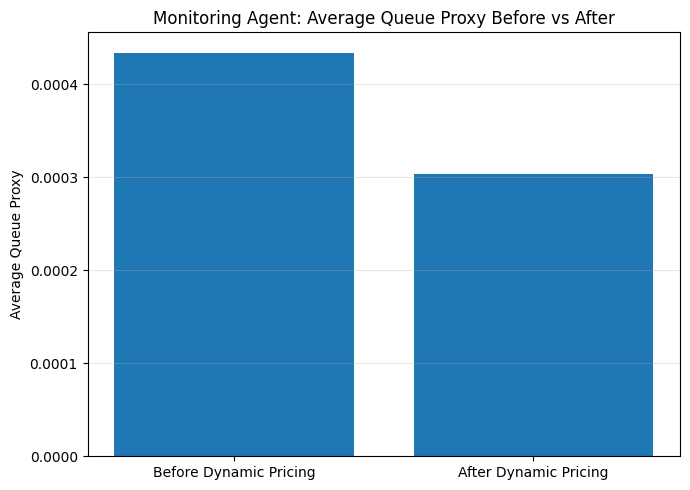

,Metric,Average Queue Proxy
0,Before Dynamic Pricing,0.000434
1,After Dynamic Pricing,0.000304


Saved: /kaggle/working/ev_tariff_outputs/plots/queue_proxy_before_after.png


In [35]:
# =========================
# 11B. Monitoring Agent: Queue Before vs After
# =========================

queue_compare = pd.DataFrame({
    "Metric": ["Before Dynamic Pricing", "After Dynamic Pricing"],
    "Average Queue Proxy": [
        monitoring_log["queue_proxy_before"].mean(),
        monitoring_log["queue_proxy_after"].mean()
    ]
})

plt.figure(figsize=(7, 5))
plt.bar(queue_compare["Metric"], queue_compare["Average Queue Proxy"])
plt.title("Monitoring Agent: Average Queue Proxy Before vs After")
plt.ylabel("Average Queue Proxy")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "queue_proxy_before_after.png", dpi=160)
plt.show()

display(queue_compare)

print("Saved:", PLOTS_DIR / "queue_proxy_before_after.png")

## 10. Final business metrics

These are the numbers you can directly use in your presentation.

In [45]:
# =========================
# 12. Final business metrics
# =========================

# Recover best model metrics
best_model_row = model_results.sort_values("RMSE").iloc[0]

best_name = best_model_row["model"]
best_rmse = best_model_row["RMSE"]
best_mae = best_model_row["MAE"]
best_r2 = best_model_row["R2"]

baseline_revenue = pred_df["baseline_revenue"].sum()
dynamic_revenue = pred_df["dynamic_revenue"].sum()

avg_queue_before = pred_df["queue_proxy_before"].mean()
avg_queue_after = pred_df["queue_proxy_after"].mean()

total_queue_before = pred_df["queue_proxy_before"].sum()
total_queue_after = pred_df["queue_proxy_after"].sum()

revenue_gain_pct = (
    (dynamic_revenue - baseline_revenue) / baseline_revenue * 100
    if baseline_revenue > 0 else 0
)

queue_proxy_reduction_pct = (
    (total_queue_before - total_queue_after) / total_queue_before * 100
    if total_queue_before > 0 else 0
)

pricing_efficiency_baseline = (
    baseline_revenue / pred_df["demand_kwh"].sum()
    if pred_df["demand_kwh"].sum() > 0 else 0
)

pricing_efficiency_dynamic = (
    dynamic_revenue / pred_df["adjusted_demand_kwh"].sum()
    if pred_df["adjusted_demand_kwh"].sum() > 0 else 0
)

# Ensure optional metrics exist safely
if "simulated_utilization_after_pricing" in pred_df.columns:
    avg_utilization_before_pricing = pred_df["predicted_utilization"].mean()
    avg_utilization_after_pricing = pred_df["simulated_utilization_after_pricing"].mean()
else:
    avg_utilization_before_pricing = np.nan
    avg_utilization_after_pricing = np.nan

if "adjusted_demand_kwh" in pred_df.columns:
    off_peak_mask = pred_df["predicted_utilization"] < 0.30

    off_peak_demand_before_kwh = pred_df.loc[off_peak_mask, "demand_kwh"].sum()
    off_peak_demand_after_kwh = pred_df.loc[off_peak_mask, "adjusted_demand_kwh"].sum()

    off_peak_uplift_pct = (
        (off_peak_demand_after_kwh - off_peak_demand_before_kwh)
        / off_peak_demand_before_kwh * 100
        if off_peak_demand_before_kwh > 0 else 0
    )
else:
    off_peak_uplift_pct = np.nan

if "customer_response_rate" not in pred_df.columns and "adjusted_demand_kwh" in pred_df.columns:
    pred_df["customer_response_rate"] = (
        (pred_df["adjusted_demand_kwh"] - pred_df["demand_kwh"])
        / pred_df["demand_kwh"].replace(0, np.nan)
    )

avg_customer_response_rate = (
    pred_df["customer_response_rate"].mean()
    if "customer_response_rate" in pred_df.columns else np.nan
)

if "pricing_efficiency_score" not in pred_df.columns and "adjusted_demand_kwh" in pred_df.columns:
    pred_df["pricing_efficiency_score"] = (
        pred_df["dynamic_revenue"]
        / pred_df["adjusted_demand_kwh"].replace(0, np.nan)
    )

avg_pricing_efficiency_score = (
    pred_df["pricing_efficiency_score"].mean()
    if "pricing_efficiency_score" in pred_df.columns else np.nan
)

avg_waiting_time_reduction_proxy = avg_queue_before - avg_queue_after

final_metrics = {
    "best_model": best_name,
    "best_mae": best_mae,
    "best_rmse": best_rmse,
    "best_r2": best_r2,
    "test_rows": len(pred_df),

    "baseline_revenue": baseline_revenue,
    "dynamic_revenue": dynamic_revenue,
    "revenue_gain_pct": revenue_gain_pct,

    "avg_queue_proxy_before": avg_queue_before,
    "avg_queue_proxy_after": avg_queue_after,
    "total_queue_proxy_before": total_queue_before,
    "total_queue_proxy_after": total_queue_after,
    "queue_proxy_reduction_pct": queue_proxy_reduction_pct,

    "avg_utilization_before_pricing": avg_utilization_before_pricing,
    "avg_utilization_after_pricing": avg_utilization_after_pricing,
    "off_peak_uplift_pct": off_peak_uplift_pct,

    "avg_customer_response_rate": avg_customer_response_rate,
    "avg_pricing_efficiency_score": avg_pricing_efficiency_score,
    "avg_waiting_time_reduction_proxy": avg_waiting_time_reduction_proxy,

    "avg_recommended_tariff": pred_df["recommended_tariff"].mean(),
    "min_recommended_tariff": pred_df["recommended_tariff"].min(),
    "max_recommended_tariff": pred_df["recommended_tariff"].max(),

    "pricing_efficiency_baseline": pricing_efficiency_baseline,
    "pricing_efficiency_dynamic": pricing_efficiency_dynamic,

    "surge_share_pct": pred_df["pricing_action"].eq("SURGE").mean() * 100,
    "discount_share_pct": pred_df["pricing_action"].eq("DISCOUNT").mean() * 100,
    "normal_share_pct": pred_df["pricing_action"].eq("NORMAL").mean() * 100
}

final_metrics_df = pd.DataFrame([final_metrics])

final_metrics_df.to_csv(
    OUTPUT_DIR / "final_business_metrics.csv",
    index=False
)

display(final_metrics_df)

print("Saved:", OUTPUT_DIR / "final_business_metrics.csv")

,best_model,best_mae,best_rmse,best_r2,test_rows,baseline_revenue,dynamic_revenue,revenue_gain_pct,avg_queue_proxy_before,avg_queue_proxy_after,...,avg_pricing_efficiency_score,avg_waiting_time_reduction_proxy,avg_recommended_tariff,min_recommended_tariff,max_recommended_tariff,pricing_efficiency_baseline,pricing_efficiency_dynamic,surge_share_pct,discount_share_pct,normal_share_pct
0,Hist Gradient Boosting,0.021926,0.03624,0.956705,27170,1.951319e+08,1.953831e+08,0.128699,0.000434,0.000304,...,14.981936,0.00013,14.980478,14.775014,25.0,15.0,15.02044,0.581524,59.698197,39.72028


Saved: /kaggle/working/ev_tariff_outputs/final_business_metrics.csv


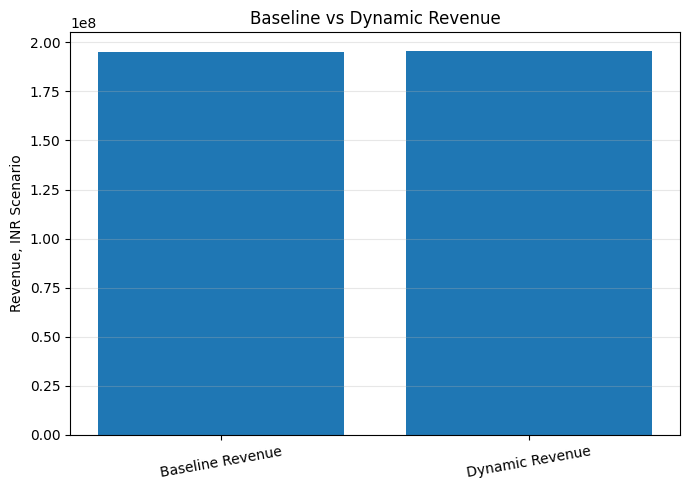

Saved: /kaggle/working/ev_tariff_outputs/plots/baseline_vs_dynamic_revenue.png


In [37]:
# =========================
# 12A. Baseline vs Dynamic Revenue Plot
# =========================

revenue_plot = pd.DataFrame({
    "type": ["Baseline Revenue", "Dynamic Revenue"],
    "value": [baseline_revenue, dynamic_revenue]
})

plt.figure(figsize=(7, 5))
plt.bar(revenue_plot["type"], revenue_plot["value"])
plt.title("Baseline vs Dynamic Revenue")
plt.ylabel("Revenue, INR Scenario")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "baseline_vs_dynamic_revenue.png", dpi=160)
plt.show()

print("Saved:", PLOTS_DIR / "baseline_vs_dynamic_revenue.png")

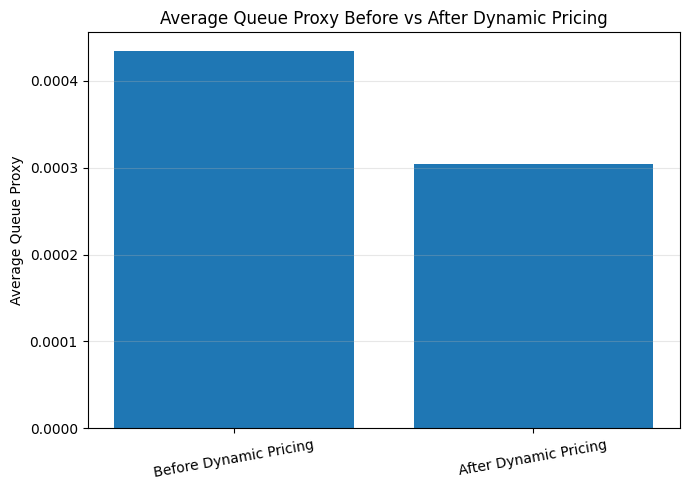

Saved: /kaggle/working/ev_tariff_outputs/plots/queue_proxy_before_after_final.png


In [38]:
# =========================
# 12B. Queue Proxy Before vs After Plot
# =========================

queue_plot = pd.DataFrame({
    "type": ["Before Dynamic Pricing", "After Dynamic Pricing"],
    "value": [avg_queue_before, avg_queue_after]
})

plt.figure(figsize=(7, 5))
plt.bar(queue_plot["type"], queue_plot["value"])
plt.title("Average Queue Proxy Before vs After Dynamic Pricing")
plt.ylabel("Average Queue Proxy")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "queue_proxy_before_after_final.png", dpi=160)
plt.show()

print("Saved:", PLOTS_DIR / "queue_proxy_before_after_final.png")

In [39]:
# =========================
# 13. Output files check
# =========================

print("Output directory:", OUTPUT_DIR)
print("\nGenerated files:")

for file in sorted(OUTPUT_DIR.glob("*")):
    print(file.name)

print("\nGenerated plots:")

for file in sorted(PLOTS_DIR.glob("*")):
    print(file.name)

Output directory: /kaggle/working/ev_tariff_outputs

Generated files:
cleaned_station_hour_data.csv
daily_demand_trend.csv
dynamic_tariff_recommendations.csv
eda_summary.csv
final_business_metrics.csv
model_results.csv
monitoring_agent_log.csv
monitoring_summary.csv
plots
predicted_utilization.csv
pricing_summary.csv

Generated plots:
actual_vs_predicted_utilization.png
avg_demand_by_hour.png
avg_utilization_by_hour.png
baseline_vs_dynamic_revenue.png
daily_demand_trend.png
demand_heatmap_day_hour.png
pricing_action_distribution.png
queue_proxy_before_after.png
queue_proxy_before_after_final.png
recommended_tariff_distribution.png
top_overloaded_stations.png
top_underutilized_stations.png
utilization_status_distribution.png
weekday_vs_weekend_demand.png


## 11. Save metadata and assumptions

These assumptions should be mentioned in the report/deck.

In [48]:
# =========================
# 15. Save project metadata
# =========================

import json
from pathlib import Path

# Make sure output folders exist
OUTPUT_DIR = Path("/kaggle/working/ev_tariff_outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Safe fallback values if variables are not currently in memory
BASE_TARIFF_SAFE = globals().get("BASE_TARIFF", 15.0)
MIN_TARIFF_SAFE = globals().get("MIN_TARIFF", 14.5)
MAX_TARIFF_SAFE = globals().get("MAX_TARIFF", 25.0)
ELASTICITY_SAFE = globals().get("ELASTICITY", -0.05)

# Safe model info
if "model_results" in globals():
    best_model_row = model_results.sort_values("RMSE").iloc[0]
    best_model_name_safe = best_model_row["model"]
    best_model_mae_safe = float(best_model_row["MAE"])
    best_model_rmse_safe = float(best_model_row["RMSE"])
    best_model_r2_safe = float(best_model_row["R2"])
else:
    best_model_name_safe = None
    best_model_mae_safe = None
    best_model_rmse_safe = None
    best_model_r2_safe = None

# Safe dataset info
if "cleaned" in globals():
    total_rows_safe = int(len(cleaned))
    total_stations_safe = int(cleaned["station_id"].nunique())
    rows_by_source_safe = cleaned["source"].value_counts().to_dict()
    stations_by_source_safe = cleaned.groupby("source")["station_id"].nunique().to_dict()

    date_range_by_source_safe = (
        cleaned
        .groupby("source")["timestamp"]
        .agg(["min", "max"])
        .astype(str)
        .to_dict()
    )
else:
    total_rows_safe = None
    total_stations_safe = None
    rows_by_source_safe = None
    stations_by_source_safe = None
    date_range_by_source_safe = None

# Safe business metrics
if "final_metrics_df" in globals():
    final_metrics_safe = final_metrics_df.iloc[0].to_dict()
else:
    final_metrics_safe = None

metadata = {
    "project_name": "ChargeOpt-AI",
    "description": "Agentic AI-based EV charging tariff optimization using ACN and UrbanEV/ST-EVCDP data.",
    "granularity": "station-hour",
    "target": "next-hour station utilization rate",

    "dataset_summary": {
        "total_rows": total_rows_safe,
        "total_stations": total_stations_safe,
        "rows_by_source": rows_by_source_safe,
        "stations_by_source": stations_by_source_safe,
        "date_range_by_source": date_range_by_source_safe
    },

    "best_model": {
        "model_name": best_model_name_safe,
        "MAE": best_model_mae_safe,
        "RMSE": best_model_rmse_safe,
        "R2": best_model_r2_safe
    },

    "pricing_setup": {
        "baseline_tariff_inr_per_kwh": BASE_TARIFF_SAFE,
        "pricing_bounds_inr_per_kwh": [MIN_TARIFF_SAFE, MAX_TARIFF_SAFE],
        "elasticity_assumption": ELASTICITY_SAFE
    },

    "final_business_metrics": final_metrics_safe,

    "assumptions": [
        "ACN price is not observed, so revenue uses a fixed ₹15/kWh baseline.",
        "Shenzhen original prices are preserved and converted to INR-scenario only for common-scale comparison.",
        "ACN station capacity is assumed to be 1 per stationID because charger capacity metadata is not available in the uploaded ACN file.",
        "Queue length is not directly observed; queue proxy is max(0, utilization_rate - 0.8).",
        "Waiting-time reduction is approximated using queue proxy reduction.",
        "Pricing results are scenario simulations, not causal claims.",
        "Demand response is simulated using a mild short-run elasticity assumption.",
        "UrbanEV is used as the main forecasting dataset because it provides dense station-level time-series data.",
        "ACN is used for session-level preprocessing and behavioral charging analysis."
    ],

    "outputs": [
        "cleaned_station_hour_data.csv",
        "eda_summary.csv",
        "source_summary.csv",
        "daily_demand_trend.csv",
        "peak_shoulder_offpeak_volatility.csv",
        "spatial_network_summary.csv",
        "model_results.csv",
        "predicted_utilization.csv",
        "dynamic_tariff_recommendations.csv",
        "pricing_summary.csv",
        "extra_tariff_metrics.csv",
        "monitoring_agent_log.csv",
        "monitoring_summary.csv",
        "additional_monitoring_metrics.csv",
        "final_business_metrics.csv",
        "assumptions_and_limitations.csv",
        "metadata.json",
        "plots/*.png"
    ]
}

with open(OUTPUT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved at:", OUTPUT_DIR / "metadata.json")
print("All outputs saved in:", OUTPUT_DIR)
print("Plots saved in:", PLOTS_DIR)

Metadata saved at: /kaggle/working/ev_tariff_outputs/metadata.json
All outputs saved in: /kaggle/working/ev_tariff_outputs
Plots saved in: /kaggle/working/ev_tariff_outputs/plots
